# Table of contents

* **Table of contents**
* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Decision Tree and Extra Tree Foundations**
* **Data Dictionary**
* **Setup Environments**
* **Data Loading**
* **Initial Data Preprocessing**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training, Experiments, and Visualization**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The objective of this project is mushroom classification, a binary prediction task determining whether a specimen is edible or poisonous based on a set of categorical features, including cap shape, odor, and habitat. The foundational dataset, sourced from Kaggle, provides 23 distinct attributes describing the physical and environmental characteristics of the mushrooms. The primary analytical focus is the construction and investigation of Decision Tree and Extra Tree Classifiers algorithm behavior on the prediction. Leveraging these tree-based models facilitates the understanding of their respective behaviors, allows for optimization of predictive performance, and enables the visualization of inherent decision logic. The analytical pipeline encompasses all essential steps: data preprocessing, exploratory data analysis (EDA), model training, hyperparameter tuning, and comprehensive assessment using statistical metrics and visualizations.

# Objective

The primary objective is to develop a robust machine learning pipeline to classify mushrooms as edible or poisonous with high accuracy. Specifically, we aim to:

- Preprocess the mushroom dataset by encoding categorical features and reducing dimensionality for visualization.
Train and compare Decision Tree and Extra Tree Classifiers, exploring different splitting criteria (Gini, entropy, log loss).
- Optimize model performance using cost-complexity pruning and grid search hyperparameter tuning.
- Evaluate model performance using metrics like accuracy, precision, recall, F1-score, and AUC-ROC, and visualize results through confusion matrices, precision-recall curves, ROC curves, decision boundaries, and tree structures.
- Provide a detailed theoretical understanding of Decision Tree and Extra Tree Classifiers, including their algorithms, strengths, and limitations.

# Pipeline Overview

The machine learning pipeline is executed through the following structured stages, designed to move from raw data to an optimized, validated model.

**A. Data Acquisition and Partitioning**

- Action: Load the mushrooms.csv dataset and perform an 80/20 train-test split using train_test_split with a fixed random seed.
- Goal: Establish two statistically independent partitions. The use of a fixed seed ensures reproducibility, while the separation is critical for preventing data leakage and obtaining an unbiased estimate of the model's performance on unseen data.

**B. Exploratory Data Analysis (EDA)**

- Action: Inspect data integrity using info(), isnull().sum(), and describe(). Visualize feature distributions (e.g., cap-shape, odor) and compute the specialized Phik correlation matrix (suitable for categorical data).
- Goal: Gain feature insight and confirm the dataset's integrity. Phik correlation quantifies the non-linear relationship between features and the target class, helping to identify high-impact features (e.g., odor, gill-color) which guide subsequent feature selection.

**C. Data Preprocessing and Transformation**

- Action: Execute Feature Selection by dropping low-correlation features (gill-attachment, stalk-shape, ring-number) to reduce computational noise and dimensionality. Apply OrdinalEncoder and LabelEncoder to convert all categorical data into numerical format. Finally, apply Principal Component Analysis (PCA) to reduce the feature set to two dimensions.
- Goal: Prepare the data for algorithmic consumption. Feature selection reduces model complexity. PCA transforms the data to a 2D space, maximizing the retained variance for visualization of the decision boundaries.

**D. Baseline Modeling and Cross-Validation**

- Action: Train the initial Decision Tree and Extra Tree Classifiers using various Splitting Criteria (Gini, Entropy, Log Loss). Performance is assessed using 10-fold Stratified Cross-Validation.
- Goal: Establish a baseline performance for both classifiers under different impurity measures. Stratified cross-validation ensures that the class distribution remains consistent across all folds, leading to a more robust estimate of the generalization error and reducing the risk of a high-variance performance estimate.

**E. Overfitting Mitigation: Cost-Complexity Pruning (CCP)**

- Action: Apply CCP to the Decision Tree, analyzing the trade-off between the tree's complexity and the resultant predictive impurity.
- Goal: Explicitly address the high-variance nature of a fully grown Decision Tree. By tuning the complexity parameter ($\text{ccp}\_\text{alpha}$), the model aims to find the optimal point on the Bias-Variance Trade-off curve, simplifying the tree to improve generalization and reduce overfitting.

**F. Hyperparameter Optimization**

- Action: Utilize GridSearchCV to systematically explore combinations of hyperparameters (e.g., criterion, max_depth, min_samples_split, ccp_alpha) for both classifiers.
- Goal: Identify the globally optimal set of hyperparameters that minimizes the out-of-sample error (validation error). This process ensures the model's architecture is optimally configured for the specific complexities of the mushroom dataset.

**G. Final Model Evaluation and Visualization**

- Action: Evaluate the best performing, optimized model on the final, unseen test set using comprehensive metrics: Accuracy, Precision, Recall, F1-score, and AUC-ROC. Visualize results using the Confusion Matrix, Precision-Recall Curve, ROC Curve, and the 2D Decision Boundary (on PCA-transformed data).
- Goal: Quantify and visualize the model's performance. Given the critical nature of the task (poisonous vs. edible), Recall (minimizing False Negatives) is prioritized. AUC-ROC assesses the model’s overall discriminative ability, while the Confusion Matrix provides granular insight into classification errors. The Decision Boundary visualization connects the abstract model to the geometric separation of classes in the feature space.

# Decision Tree and Extra Tree Foundations

**From Data to Decision**

The classification task addresses a critical real-world problem—predicting mushroom toxicity—using a rich dataset characterized by categorical features (e.g., odor, cap shape). The complexity of the feature space necessitates models capable of handling high dimensionality and non-linear relationships. This analysis employs and contrasts two powerful, non-parametric, ensemble-capable machine learning algorithms: the Decision Tree Classifier and the Extra Tree Classifier.

The analytical pipeline is structured to ensure model robustness: starting with data preprocessing to prepare the high-dimensional categorical input, proceeding through Exploratory Data Analysis (EDA) to understand feature impact, and culminating in advanced techniques like hyperparameter tuning and cost-complexity pruning to achieve optimal generalization performance.

**I. Preprocessing and Feature Engineering**

**A. Data Leakage and Splitting**

The pipeline starts with an 80/20 train-test split. This is a mandatory step to prevent data leakage, ensuring the test set remains an unseen data representation, providing an unbiased estimate of the model's generalization error.

**B. Encoding Categorical Features**

Since Decision Trees and Extra Trees require numerical inputs, all categorical features must be converted.

- Ordinal Encoding: Applied to features where there is no inherent ordering of the categories, such as cap shape or odor. While one-hot encoding is common, tree models can often handle the arbitrarily assigned integer values from Ordinal Encoding effectively without requiring hundreds of extra columns.

- Label Encoding: Specifically applied to the binary target variable (edible/poisonous), converting it into 0s and 1s for model consumption.

**C. Dimensionality Reduction (PCA)**

Principal Component Analysis (PCA) is an unsupervised linear transformation technique used here primarily for visualization. It projects the high-dimensional feature space onto a lower-dimensional subspace (2D in this case) while retaining the maximum possible variance. The resulting 2D space allows for the plotting of decision boundaries, enabling a visual assessment of how effectively the model separates the two classes.

**II. Tree-Based Classifiers**

Tree-based methods are non-linear models that partition the feature space into a set of rectangular regions. The prediction is constant within each region.

**A. Decision Tree Classifier (DTC)**

The Decision Tree is a fundamental supervised learning model that constructs a flow-chart-like structure, where each internal node represents a test on a feature, each branch represents the outcome of the test, and each leaf node holds the class label (edible or poisonous).

**1. The Partitioning Algorithm: Recursive Binary Splitting**

DTC employs a greedy, top-down, recursive approach known as Recursive Binary Splitting. Starting at the root node, the algorithm systematically searches through all possible features and all possible split points (thresholds) to find the division that results in the greatest reduction in impurity. The decision at any node is locally optimal, although the overall tree may not be globally optimal.

**2. Splitting Criteria (Measures of Impurity)**

The core mechanism for determining the best split is the impurity function. The goal is to maximize the information gain (the reduction in impurity) after the split.

- Gini Impurity (or Gini Index): Measures how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. A Gini score of 0 means perfect purity.

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} (P_i)^2$$

where $P_i$ is the probability of class $i$ at node $t$.

- Entropy: Measures the degree of randomness or uncertainty in the node's class distribution. Maximizing information gain is equivalent to minimizing entropy.

$$\text{Entropy}(t) = - \sum_{i=1}^{C} P_i \log_2(P_i)$$

- Log Loss (Cross-Entropy): Often used in implementations like scikit-learn, it penalizes probabilistic errors. While fundamentally similar to entropy, its application in tree splitting is often about minimizing the loss associated with the resultant class probabilities.

**3. Strengths and Limitations**

- Strength: Highly interpretable (the path from root to leaf is transparent), requires minimal feature preprocessing (no scaling needed), and handles categorical data well through appropriate encoding.

- Limitation: Prone to overfitting (creating overly complex trees that memorize the training data), which requires techniques like pruning to mitigate. Small variations in the training data can lead to drastically different tree structures (high variance).

**B. Extra Tree Classifier (Extremely Randomized Trees)**

The Extra Tree Classifier is an ensemble method that builds multiple de-correlated decision trees (an ensemble) and aggregates their predictions, typically by voting. It is conceptually similar to a Random Forest but introduces two key differences to further increase randomness and reduce variance:

- Random Feature Subsets: Like Random Forest, each tree is trained on a random subset of features.

- Randomized Split Points: Instead of calculating the locally optimal split point (as DTC does), Extra Trees select a split point randomly for each candidate feature. It then uses the best of these random splits.

**1. Impact of Randomization**

By introducing extreme randomization in both the feature selection and the split point calculation, the ExtRa Tree Classifier achieves:

- Lower Variance: The high randomization ensures that the individual trees in the ensemble are heavily de-correlated, significantly reducing the variance of the final aggregated prediction.
- Increased Speed: Finding the best split threshold is computationally expensive. Randomly selecting a split point dramatically reduces training time compared to standard Decision Trees or Random Forests.

**2. Strengths**

- Excellent at variance reduction compared to a single Decision Tree.
- Significantly faster to train than Random Forests due to the random split point selection.
- Maintains strong predictive accuracy, often rivaling Random Forest.

**III. Model Optimization and Evaluation Techniques**

The goal is not just to train a tree, but to find the simplest tree that generalizes well—a concept known as Occam's Razor.

**A. Cost-Complexity Pruning (CCP)**

CCP is a technique used to mitigate overfitting in Decision Trees by simplifying the tree after it has been fully grown.

- Concept: CCP introduces a penalty term ($\alpha$) to the overall impurity calculation, balancing the model's complexity (tree size) with its predictive error (impurity).

$$\text{Pruned Tree Score} = \text{Impurity} + \alpha \cdot |\text{Leaves}|$$

- Procedure: A sequence of increasingly pruned subtrees is generated by gradually increasing the value of the complexity parameter ($\text{ccp}\_\text{alpha}$). The optimal $\text{ccp}\_\text{alpha}$ is then selected using cross-validation to find the point where the error rate on the validation set is minimized. This ensures the resulting tree avoids the high variance of a fully grown tree while retaining sufficient predictive power.

**B. Hyperparameter Tuning (Grid Search)**

Hyperparameters are parameters whose values control the learning process and are set before training begins (e.g., max_depth, min_samples_split). GridSearchCV systematically searches over a predefined combination of hyperparameter values to find the configuration that yields the best performance metric (e.g., highest accuracy or F1-score) as determined by cross-validation. This process is essential to prevent both underfitting (if the model is too simple) and overfitting (if the model is too complex).

**C. Evaluation Metrics and Visualizations**

Model assessment must go beyond simple accuracy, especially in binary classification.

- Confusion Matrix: A $2 \times 2$ table visualizing the performance of the classification model, showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

Precision, Recall, and F1-Score: These metrics are derived from the Confusion Matrix.

- Precision: $\text{TP} / (\text{TP} + \text{FP})$. The ratio of correctly predicted positive observations to the total predicted positives. Essential for minimizing false alarms (e.g., incorrectly classifying an edible mushroom as poisonous).

- Recall (Sensitivity): $\text{TP} / (\text{TP} + \text{FN})$. The ratio of correctly predicted positive observations to all observations in the actual class. Critical for minimizing false negatives (e.g., incorrectly classifying a poisonous mushroom as edible, the most dangerous error).

- F1-Score: The harmonic mean of Precision and Recall. A balanced metric for scenarios where both False Positives and False Negatives are important.

Receiver Operating Characteristic (ROC) Curve and AUC:

- ROC Curve: Plots the True Positive Rate (Recall) against the False Positive Rate (FPR) at various threshold settings.

- Area Under the Curve (AUC): Measures the entire two-dimensional area underneath the ROC curve. An AUC of 1.0 indicates a perfect model, while 0.5 suggests performance no better than random guessing. AUC is a robust metric for assessing the model's overall discriminative ability across all possible thresholds.

- Feature Importance: Tree-based models can intrinsically provide a score for how useful each feature was in the decision-making process (typically based on the total reduction in impurity it brought to the tree). This provides valuable insights during EDA and potentially suggests features for removal (like the low-correlation features in the preprocessing step).

# Data Dictionary

**Mushroom Dataset Data Dictionary**

This data dictionary outlines the attributes of the mushroom dataset, detailing each feature and its possible categorical values.

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-0pky{border-color:inherit;text-align:left;vertical-align:top}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Attribute</th>
    <th class="tg-za14">Description</th>
    <th class="tg-0pky">Values &amp; Explanations</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-za14">Class</td>
    <td class="tg-za14">Denotes whether the mushroom is edible or poisonous.</td>
    <td class="tg-0pky">e: edible, p: poisonous</td>
  </tr>
  <tr>
    <td class="tg-za14">cap-shape</td>
    <td class="tg-za14">Describes the shape of the mushroom's cap.</td>
    <td class="tg-0pky">b: bell, c: conical, x: convex, f: flat, k: knobbed, s: sunken</td>
  </tr>
  <tr>
    <td class="tg-za14">cap-surface</td>
    <td class="tg-za14">Describes the texture of the mushroom's cap surface.</td>
    <td class="tg-0pky">f: fibrous, g: grooves, y: scaly, s: smooth</td>
  </tr>
  <tr>
    <td class="tg-za14">cap-color</td>
    <td class="tg-za14">Describes the color of the mushroom's cap.</td>
    <td class="tg-0pky">n: brown, b: buff, c: cinnamon, g: gray, r: green, p: pink, u: purple, e: red, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-za14">bruises</td>
    <td class="tg-za14">Indicates the presence or absence of bruises on the mushroom.</td>
    <td class="tg-za14">t: bruises, f: no</td>
  </tr>
  <tr>
    <td class="tg-za14">odor</td>
    <td class="tg-za14">Describes the odor of the mushroom.</td>
    <td class="tg-0pky">a: almond, l: anise, c: creosote, y: fishy, f: foul, m: musty, n: none, p: pungent, s: spicy</td>
  </tr>
  <tr>
    <td class="tg-za14">gill-attachment</td>
    <td class="tg-za14">Describes how the gills are attached to the mushroom's stalk.</td>
    <td class="tg-0pky">a: attached, d: descending, f: free, n: notched</td>
  </tr>
  <tr>
    <td class="tg-za14">gill-spacing</td>
    <td class="tg-za14">Describes the spacing between the mushroom's gills.</td>
    <td class="tg-0pky">c: close, w: crowded, d: distant</td>
  </tr>
  <tr>
    <td class="tg-za14">gill-size</td>
    <td class="tg-za14">Describes the size of the mushroom's gills.</td>
    <td class="tg-0pky">b: broad, n: narrow</td>
  </tr>
  <tr>
    <td class="tg-za14">gill-color</td>
    <td class="tg-za14">Describes the color of the mushroom's gills.</td>
    <td class="tg-0pky">k: black, n: brown, b: buff, h: chocolate, g: gray, r: green, o: orange, p: pink, u: purple, e: red, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-shape</td>
    <td class="tg-za14">Describes the shape of the mushroom's stalk.</td>
    <td class="tg-0pky">e: enlarging, t: tapering</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-root</td>
    <td class="tg-za14">Describes the type of root at the base of the mushroom's stalk.</td>
    <td class="tg-0pky">b: bulbous, c: club, u: cup, e: equal, z: rhizomorphs, r: rooted, ?: missing</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-surface-above-ring</td>
    <td class="tg-za14">Describes the texture of the mushroom's stalk surface above the ring.</td>
    <td class="tg-0pky">f: fibrous, y: scaly, k: silky, s: smooth</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-surface-below-ring</td>
    <td class="tg-za14">Describes the texture of the mushroom's stalk surface below the ring.</td>
    <td class="tg-0pky">f: fibrous, y: scaly, k: silky, s: smooth</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-color-above-ring</td>
    <td class="tg-za14">Describes the color of the mushroom's stalk above the ring.</td>
    <td class="tg-0pky">n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-za14">stalk-color-below-ring</td>
    <td class="tg-za14">Describes the color of the mushroom's stalk below the ring.</td>
    <td class="tg-0pky">n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-za14">veil-type</td>
    <td class="tg-za14">Describes the type of veil present on the mushroom.</td>
    <td class="tg-0pky">p: partial, u: universal</td>
  </tr>
  <tr>
    <td class="tg-za14">veil-color</td>
    <td class="tg-za14">Describes the color of the mushroom's veil.</td>
    <td class="tg-0pky">n: brown, o: orange, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-7zrl">ring-number</td>
    <td class="tg-7zrl">Describes the number of rings on the mushroom's stalk.</td>
    <td class="tg-0lax">n: none, o: one, t: two</td>
  </tr>
  <tr>
    <td class="tg-7zrl">ring-type</td>
    <td class="tg-7zrl">Describes the type of ring on the mushroom's stalk.</td>
    <td class="tg-0lax">c: cobwebby, e: evanescent, f: flaring, l: large, n: none, p: pendant, s: sheathing, z: zone</td>
  </tr>
  <tr>
    <td class="tg-7zrl">spore-print-color</td>
    <td class="tg-7zrl">Describes the color of the mushroom's spore print.</td>
    <td class="tg-0lax">k: black, n: brown, b: buff, h: chocolate, r: green, o: orange, u: purple, w: white, y: yellow</td>
  </tr>
  <tr>
    <td class="tg-7zrl">population</td>
    <td class="tg-7zrl">Describes the population density or grouping of the mushrooms.</td>
    <td class="tg-0lax">a: abundant, c: clustered, n: numerous, s: scattered, v: several, y: solitary</td>
  </tr>
  <tr>
    <td class="tg-7zrl">habitat</td>
    <td class="tg-7zrl">Describes the natural habitat where the mushroom grows.</td>
    <td class="tg-0lax">g: grasses, l: leaves, m: meadows, p: paths, u: urban, w: waste, d: woods</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/uciml/mushroom-classification/data)**

# Setup Environments

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold, GridSearchCV, cross_val_predict
from phik import phik_matrix
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, precision_recall_curve, auc, roc_curve

warnings.filterwarnings('ignore')

# Data Loading

In [3]:
df = pd.read_csv('/kaggle/input/mushroom-classification/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# Initial Data Preprocessing

Update columns with values for better visualization and information

In [4]:
class_mapping = {'e': 'edible', 'p': 'poisonous'}
cap_shape_mapping = {'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat', 'k': 'knobbed', 's': 'sunken'}
cap_surface_mapping = {'f': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth'}
cap_color_mapping = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'r': 'green', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'}
bruises_mapping = {'t': 'bruises', 'f': 'no'}
odor_mapping = {'a': 'almond', 'l': 'anise', 'c': 'creosote', 'y': 'fishy', 'f': 'foul', 'm': 'musty', 'n': 'none', 'p': 'pungent', 's': 'spicy'}
gill_attachment_mapping = {'a': 'attached', 'd': 'descending', 'f': 'free', 'n': 'notched'}
gill_spacing_mapping = {'c': 'close', 'w': 'crowded', 'd': 'distant'}
gill_size_mapping = {'b': 'broad', 'n': 'narrow'}
gill_color_mapping = {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'g': 'gray', 'r': 'green', 'o': 'orange', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'}
stalk_shape_mapping = {'e': 'enlarging', 't': 'tapering'}
stalk_root_mapping = {'b': 'bulbous', 'c': 'club', 'u': 'cup', 'e': 'equal', 'z': 'rhizomorphs', 'r': 'rooted', '?': 'missing'}
stalk_surface_above_ring_mapping = {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'}
stalk_surface_below_ring_mapping = {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'}
stalk_color_above_ring_mapping = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'}
stalk_color_below_ring_mapping = {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'}
veil_type_mapping = {'p': 'partial', 'u': 'universal'}
veil_color_mapping = {'n': 'brown', 'o': 'orange', 'w': 'white', 'y': 'yellow'}
ring_number_mapping = {'n': 'none', 'o': 'one', 't': 'two'}
ring_type_mapping = {'c': 'cobwebby', 'e': 'evanescent', 'f': 'flaring', 'l': 'large', 'n': 'none', 'p': 'pendant', 's': 'sheathing', 'z': 'zone'}
spore_print_color_mapping = {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'r': 'green', 'o': 'orange', 'u': 'purple', 'w': 'white', 'y': 'yellow'}
population_mapping = {'a': 'abundant', 'c': 'clustered', 'n': 'numerous', 's': 'scattered', 'v': 'several', 'y': 'solitary'}
habitat_mapping = {'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths', 'u': 'urban', 'w': 'waste', 'd': 'woods'}

attribute_mappings = {
    'class': class_mapping,
    'cap-shape': cap_shape_mapping,
    'cap-surface': cap_surface_mapping,
    'cap-color': cap_color_mapping,
    'bruises': bruises_mapping,
    'odor': odor_mapping,
    'gill-attachment': gill_attachment_mapping,
    'gill-spacing': gill_spacing_mapping,
    'gill-size': gill_size_mapping,
    'gill-color': gill_color_mapping,
    'stalk-shape': stalk_shape_mapping,
    'stalk-root': stalk_root_mapping,
    'stalk-surface-above-ring': stalk_surface_above_ring_mapping,
    'stalk-surface-below-ring': stalk_surface_below_ring_mapping,
    'stalk-color-above-ring': stalk_color_above_ring_mapping,
    'stalk-color-below-ring': stalk_color_below_ring_mapping,
    'veil-type': veil_type_mapping,
    'veil-color': veil_color_mapping,
    'ring-number': ring_number_mapping,
    'ring-type': ring_type_mapping,
    'spore-print-color': spore_print_color_mapping,
    'population': population_mapping,
    'habitat': habitat_mapping,
}

for column, mapping in attribute_mappings.items():
    df[column] = df[column].replace(mapping)

**Train and Test Split**

Split dataset into train and test dataset to prevent data leakage problem

In [5]:
# Split the data into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42) 

# Print the shapes of the resulting sets
#print("X_train shape:", x_train.shape)
print("df_train shape:", df_train.shape)
#print("X_test shape:", x_test.shape)
print("df_test shape:", df_test.shape)

df_train shape: (6499, 23)
df_test shape: (1625, 23)


# Exploratory Data Analysis (EDA)

Data visualization is a critical step in Exploratory Data Analysis (EDA) and model evaluation. Libraries like matplotlib.pyplot, seaborn, and plotly.express provide powerful tools to create various types of plots, helping to understand data distributions, relationships, and model performance visually.

**Basic statistics**

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6499 entries, 7873 to 7270
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     6499 non-null   object
 1   cap-shape                 6499 non-null   object
 2   cap-surface               6499 non-null   object
 3   cap-color                 6499 non-null   object
 4   bruises                   6499 non-null   object
 5   odor                      6499 non-null   object
 6   gill-attachment           6499 non-null   object
 7   gill-spacing              6499 non-null   object
 8   gill-size                 6499 non-null   object
 9   gill-color                6499 non-null   object
 10  stalk-shape               6499 non-null   object
 11  stalk-root                6499 non-null   object
 12  stalk-surface-above-ring  6499 non-null   object
 13  stalk-surface-below-ring  6499 non-null   object
 14  stalk-color-above-ring    

In [7]:
df_train.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [8]:
df_train.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,6499,6499,6499,6499,6499,6499,6499,6499,6499,6499,...,6499,6499,6499,6499,6499,6499,6499,6499,6499,6499
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,edible,convex,scaly,brown,no,none,free,close,broad,buff,...,smooth,white,white,partial,white,one,pendant,white,several,woods
freq,3365,2956,2602,1823,3802,2833,6331,5451,4496,1398,...,3944,3573,3502,6499,6340,5976,3154,1936,3218,2513


**Categorical Features Distribution**

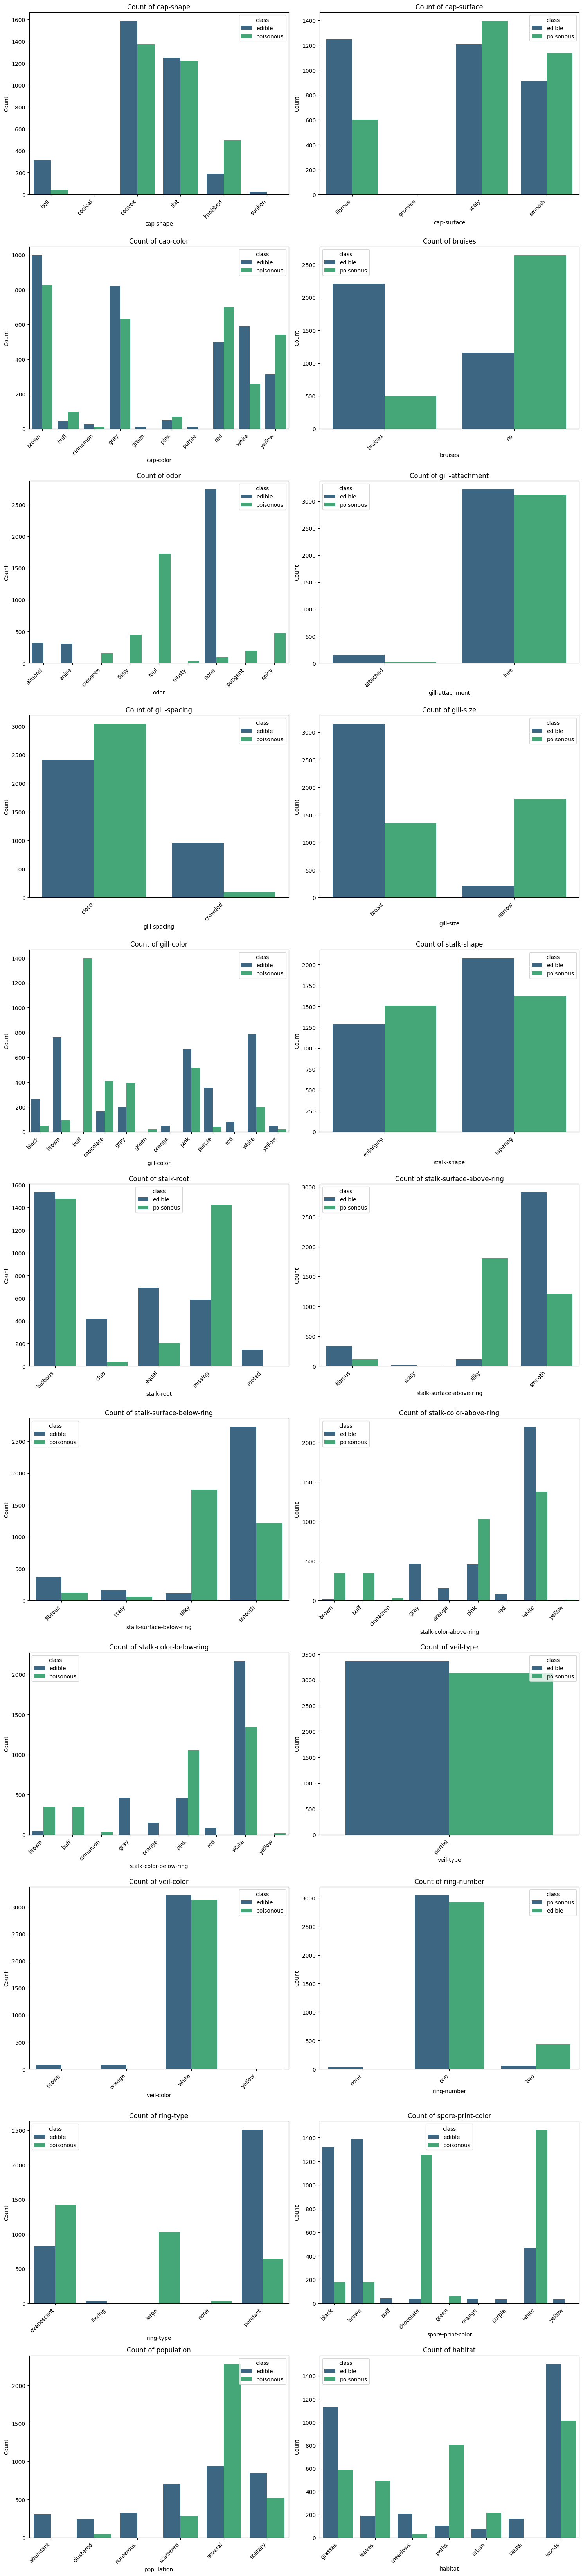

In [9]:
def plot_count(x,ax):
    group = df_train.groupby([f'{x}','class'])['class'].count().reset_index(name='Count')
    sns.barplot(data=group,x=x,y='Count',hue='class',palette='viridis',ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'Count of {x}')
cols = df.columns.tolist()
fig, axes = plt.subplots(11, 2, figsize=(15, 6 * 11))

for index,column in enumerate(cols[1:]):
    row = index // 2 
    col = index % 2
    ax = axes[row,col]
    plot_count(column, ax)
    
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(23, 18))
fig_pie = px.pie(df_train,names="habitat",title="Habitat Distribution")
fig_pie.show()

<Figure size 2300x1800 with 0 Axes>

**Bivariate Analysis**

In [ ]:
plt.figure(figsize=(23, 18))
fig_scatter = px.scatter(df_train, x='population', y='habitat', color='class', title='Population vs Habitat: Edible vs Poisonous')
fig_scatter.show()

<Figure size 2300x1800 with 0 Axes>

**Target Labels Distribution**

In [60]:
df_train['class'].value_counts(normalize=True)

class
edible       0.517772
poisonous    0.482228
Name: proportion, dtype: float64

In [ ]:
fig_pie = px.pie(df_train,names="class",title="Class Distribution (Target Label)")
fig_pie.show()

**Correlation Analysis**

The code provided performs a Phik correlation check, which is a method used to measure the correlation between categorical, ordinal, and numerical variables in a dataset. Unlike traditional correlation coefficients (like Pearson's r), Phik is designed to capture non-linear relationships and is particularly robust for mixed data types, making it suitable for datasets with many categorical features like the mushroom dataset.


Why Phik Correlation?
* Handles Categorical Data: Standard correlation measures (like Pearson) are designed for numerical data and don't effectively capture relationships between categorical variables. Phik addresses this limitation by adapting concepts from mutual information and chi-squared tests, providing a more appropriate measure for such data.

* Captures Non-Linear Relationships: Phik can identify both linear and non-linear dependencies between variables, offering a more comprehensive understanding of their relationships.

* Symmetric and Normalized: The Phik coefficient ranges from 0 to 1 (or -1 to 1 for signed Phik), where 0 indicates no dependency and 1 (or -1) indicates a perfect dependency, making it easy to interpret.

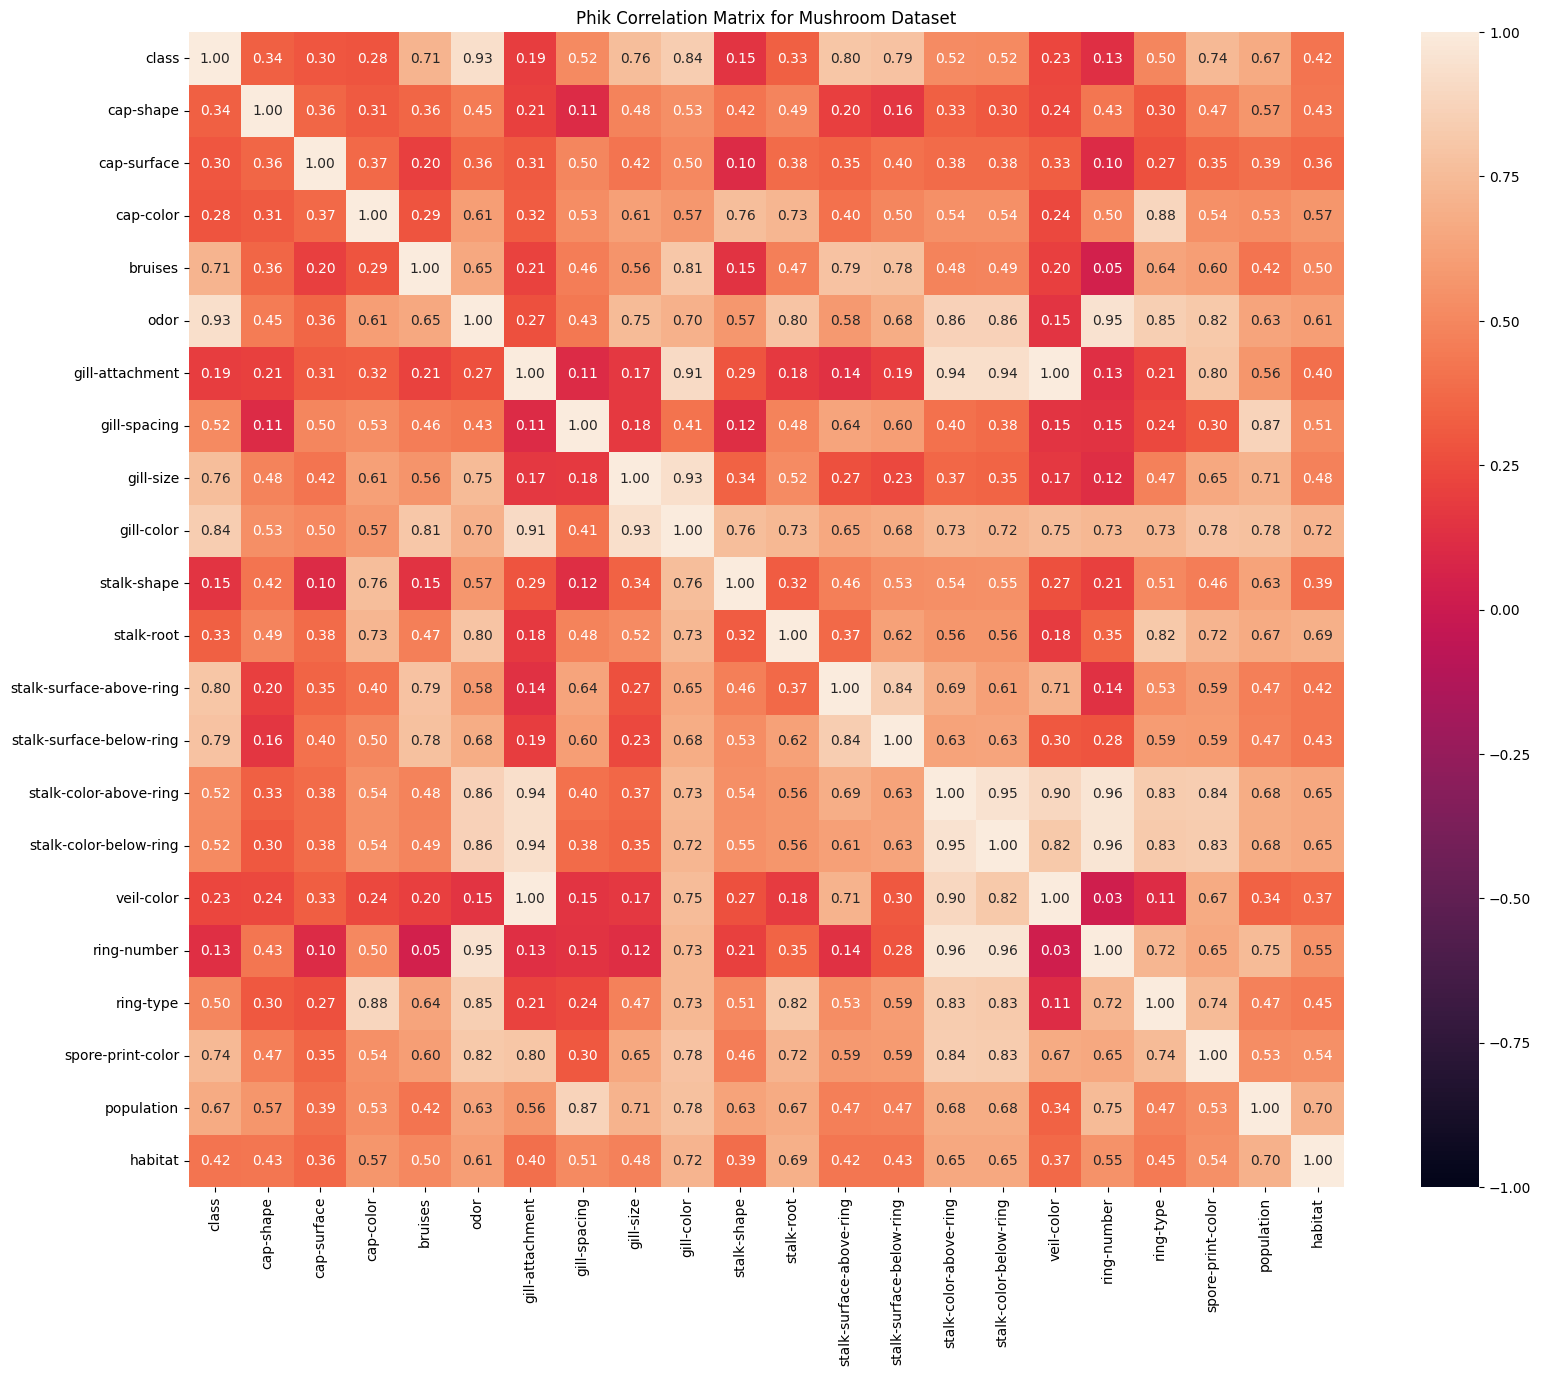

In [ ]:
phik_correlation = phik_matrix(df_train, interval_cols=[])  

plt.figure(figsize=(20, 15))
sns.heatmap(phik_correlation, annot=True, cmap="rocket", vmin=-1, vmax=1, center=0, square=True, fmt='.2f')
plt.title("Phik Correlation Matrix for Mushroom Dataset")
plt.show()

In [ ]:
target_correlations = phik_correlation['class'].sort_values(ascending=False)
print("\nCorrelations with Target 'class':")
print(target_correlations.round(2))


Correlations with Target 'class':
class                       1.00
odor                        0.93
gill-color                  0.84
stalk-surface-above-ring    0.80
stalk-surface-below-ring    0.79
gill-size                   0.76
spore-print-color           0.74
bruises                     0.71
population                  0.67
stalk-color-above-ring      0.52
gill-spacing                0.52
stalk-color-below-ring      0.52
ring-type                   0.50
habitat                     0.42
cap-shape                   0.34
stalk-root                  0.33
cap-surface                 0.30
cap-color                   0.28
veil-color                  0.23
gill-attachment             0.19
stalk-shape                 0.15
ring-number                 0.13
Name: class, dtype: float64


# Features Engineering

**Noise Reduction**

Drop columns that are no-relationship with target label. To simplify the dataset, reduce computational cost, and potentially improve model performance by removing features that do not contribute meaningfully to the prediction (Reducing Noise and Redundancy).

In [ ]:
columns_to_drop = ['gill-attachment', 'stalk-shape ', 'ring-number '] 
df_train = df_train.drop(columns=columns_to_drop, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')

**Features and Target Labels Split**

Separate features and target labels. To prepare the data in the standard format required by most machine learning algorithms, allowing the model to learn from features and predict the target.

In [ ]:
y_train = df_train['class'] 
x_train = df_train.drop('class', axis=1) 
y_test = df_test['class'] 
x_test = df_test.drop('class', axis=1) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6499, 21)
y_train shape: (6499,)
X_test shape: (1625, 21)
y_test shape: (1625,)


**Features Encoding**

To convert non-numeric categorical data into a numerical format that machine learning algorithms can process, `OrdinalEncoder` is used to encode categorical feature. `OrdinalEncoder` assigns a unique integer to each unique category. For example, if 'cap-shape' has categories 'bell', 'conical', 'flat', it might encode them as 0, 1, 2. This type of encoding is suitable when there is an inherent order or ranking among the categories (though for mushroom features, this might be an assumption or a simpler choice than one-hot encoding if no order is implied).

It's crucial to fit the encoder only on the training data (`x_train`) and then use the fitted encoder to transform both training and test data. This prevents data leakage, where information from the test set inadvertently influences the training process, leading to an overly optimistic evaluation of the model.

In [ ]:
encoder = OrdinalEncoder()

x_train_encoded = encoder.fit_transform(x_train)
x_test_encoded = encoder.transform(x_test)

x_train = pd.DataFrame(x_train_encoded, columns=x_train.columns)
x_test = pd.DataFrame(x_test_encoded, columns=x_test.columns)
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap-shape                 6499 non-null   float64
 1   cap-surface               6499 non-null   float64
 2   cap-color                 6499 non-null   float64
 3   bruises                   6499 non-null   float64
 4   odor                      6499 non-null   float64
 5   gill-spacing              6499 non-null   float64
 6   gill-size                 6499 non-null   float64
 7   gill-color                6499 non-null   float64
 8   stalk-shape               6499 non-null   float64
 9   stalk-root                6499 non-null   float64
 10  stalk-surface-above-ring  6499 non-null   float64
 11  stalk-surface-below-ring  6499 non-null   float64
 12  stalk-color-above-ring    6499 non-null   float64
 13  stalk-color-below-ring    6499 non-null   float64
 14  veil-typ

**Target Labels Encoding**

Similar to feature encoding, `LabelEncoder` is used here to convert the categorical target variable ('class', e.g., 'edible' or 'poisonous') into numerical labels. It maps each unique class name to a unique integer. `LabelEncoder` is specifically designed for target variables. For a binary classification like 'edible'/'poisonous', it might map 'edible' to 0 and 'poisonous' to 1. The same encoder fitted on `y_train` must be used to transform `y_test` to ensure consistent mapping.

In [ ]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\nLabel mapping after encoding:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} : {i}")


Label mapping after encoding:
edible : 0
poisonous : 1


In [68]:
x_train_nopca = x_train.copy()
x_test_nopca = x_test.copy()

To reduce the complexity of the data, potentially improve model training speed, mitigate the "curse of dimensionality," and enable visualization of high-dimensional data. Principal Component Analysis (PCA) is applied to reduce the dimensionality of the feature space from 21 columns to 2 principal components (n_components=2). This transformed data is then visualized using a scatter plot, where points are colored according to their target class.

**Dimensionality reduction (PCA)**

* **Dimensionality Reduction**: PCA is a statistical technique that transforms high-dimensional data into a lower-dimensional space while retaining as much variance (information) as possible. It creates new, uncorrelated variables called principal components (PC1, PC2, etc.), which are linear combinations of the original features.

* **Variance Maximization**: The first principal component (PC1) captures the most variance in the data, the second (PC2) captures the second most, and so on.

* **Visualization**: Reducing the data to 2 or 3 dimensions allows for easy visualization, helping to understand the separability of classes in the reduced feature space. If classes are well-separated in the PCA plot, it suggests that a classifier might perform well.

* **Noise Reduction**: PCA can also help in reducing noise by focusing on the most significant variance in the data.

In [ ]:
pca = PCA(n_components=2)  
x_train = pca.fit_transform(x_train) 
x_test = pca.transform(x_test)  

**Dimensionality Visualization**

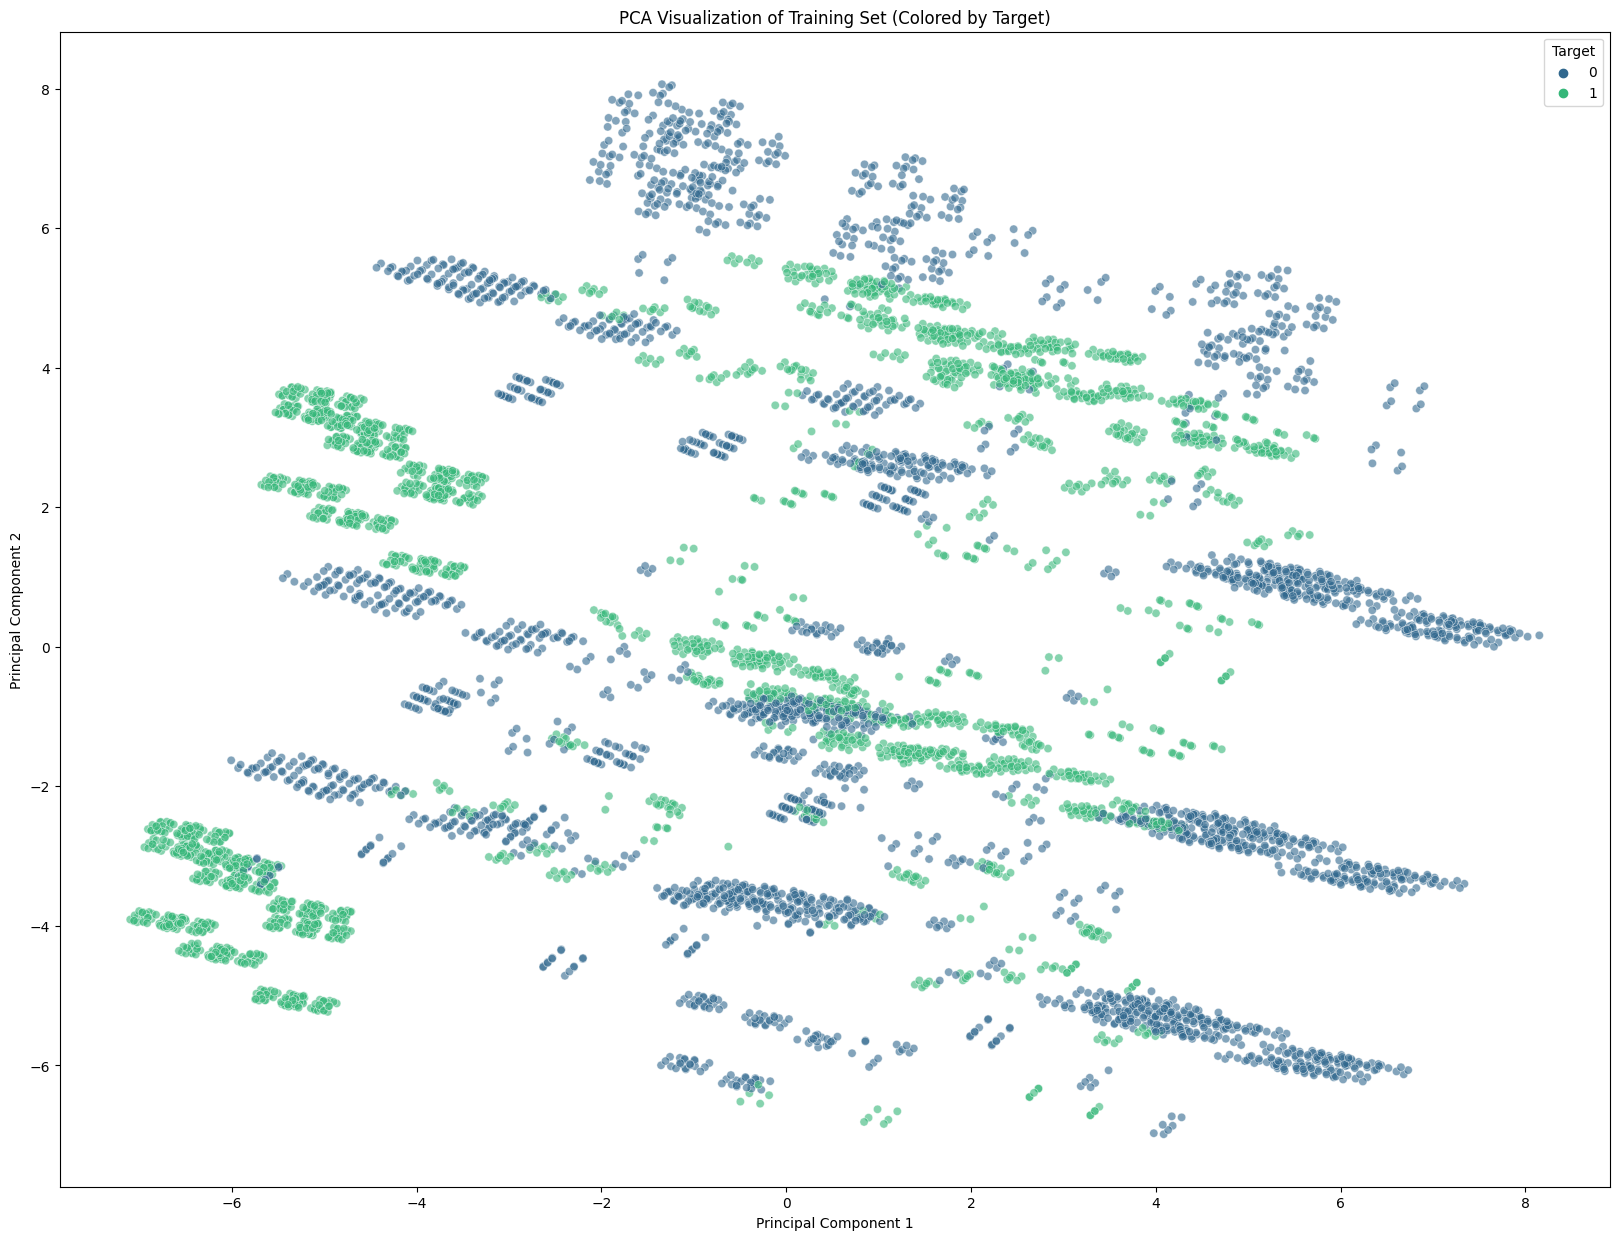

In [ ]:
x_train_pca_df = pd.DataFrame(x_train, columns=['PC1', 'PC2'])
x_test_pca_df = pd.DataFrame(x_test, columns=['PC1', 'PC2'])

plot_data = pd.DataFrame({
    'PC1': x_train_pca_df['PC1'],  
    'PC2': x_train_pca_df['PC2'],  
    'Target': y_train              
})

plt.figure(figsize=(20, 15))  
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",  
    palette="viridis",  
    alpha=0.6  
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Training Set (Colored by Target)")

plt.show()

# Model Training, Experiments, and Visaulization

This section focuses on training and evaluating Decision Tree-based models, exploring different impurity criteria, and visualizing their decision boundaries and tree structures.

**Decision Tree vs. Extra Tree Classifiers: Theory and Comparison**

This section grounds the experimental results in the theoretical mechanics of tree-based models and the robustness provided by stratified validation.

**I. Decision Tree Classifier (DTC)**

The Decision Tree Classifier is a fundamental non-parametric supervised learning model . It functions by recursively partitioning the feature space into hyper-rectangular regions, creating a flow-chart-like structure.

**Core Mechanism: Recursive Binary Splitting**

The splitting is based on a set of splitting rules based on classification features. This process is repeated on each derived subset in a recursive manner called recursive partitioning. The recursion is completed when the subset at a node has all the same values of the target variable, or when splitting no longer adds value to the predictions. 

DTC uses a greedy algorithm to build the tree: at every internal node, it assesses all available features and all possible split points (thresholds) for those features. The algorithm selects the split that maximizes the Information Gain—the largest reduction in impurity (or uncertainty) in the resulting child nodes.

**The common measures of impurity used as splitting criteria are:**

- Gini Impurity: Measures the probability of misclassifying a randomly chosen element in the node. The goal is to drive Gini impurity towards 0 (perfect purity).

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} (P_i)^2$$

- Entropy: Measures the randomness or disorder of the class labels at the node. Maximizing Information Gain is equivalent to minimizing Entropy.

$$\text{Entropy}(t) = - \sum_{i=1}^{C} P_i \log_2(P_i)$$

**Vulnerability: Overfitting**

A single, fully-grown Decision Tree has high variance, meaning it is highly sensitive to small changes in the training data. This often results in overfitting, where the tree memorizes the training examples and performs poorly on unseen data. This vulnerability necessitates optimization techniques like Cost-Complexity Pruning (CCP).

**II. Extra Tree Classifier (ETC)**

The Extra Tree Classifier, or Extremely Randomized Tree, is an ensemble learning method that seeks to address the high variance of a single DTC. It builds a large collection (an ensemble) of de-correlated decision trees and aggregates their predictions (typically by majority voting).

**Key Strategy: Extreme Randomization**

ETC shares its ensemble nature with the Random Forest, but introduces a crucial extra layer of randomness to aggressively reduce variance:

- Feature Subsetting (Shared): Like Random Forest, each tree is trained using a random subset of the input features.
- Random Split Points (Differentiating Factor): For each feature candidate, the Extra Tree does not search for the optimal split threshold that maximizes information gain. Instead, it selects a split point randomly. It then compares the performance of these random splits across the candidate features and chooses the best random split.

This extreme randomization ensures that the individual trees within the ensemble are highly diverse (low correlation), which effectively averages out the individual errors and significantly reduces the overall variance of the final model, often leading to better generalization.

**III. The Crucial Difference: Split Point Selection**

The primary theoretical and practical difference lies in how the split is determined at each node:

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-bobw{font-weight:bold;text-align:center;vertical-align:bottom}
.tg .tg-0lvq{border-color:inherit;color:#1B1C1D;font-size:100%;font-weight:bold;text-align:center;vertical-align:bottom}
.tg .tg-amwm{font-weight:bold;text-align:center;vertical-align:top}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-0lvq"><span style="font-weight:bold">Feature</span></th>
    <th class="tg-bobw"><span style="font-weight:bold">Decision Tree Classifier (DTC)</span></th>
    <th class="tg-amwm">Extra Tree Classifier (ETC)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Split Point Selection</td>
    <td class="tg-7zrl">Searches through all possible thresholds for a given feature to find the mathematically optimal split (maximizes Information Gain).</td>
    <td class="tg-0lax">Selects a random threshold for a given feature and evaluates it. Chooses the best of these random splits.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Bias-Variance</td>
    <td class="tg-7zrl">Higher Variance, lower bias (more prone to overfitting the training data).</td>
    <td class="tg-0lax">Lower Variance, potentially slightly higher bias (more robust to unseen data).</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Training Speed</td>
    <td class="tg-7zrl">Slower, due to the comprehensive search for the optimal split.</td>
    <td class="tg-0lax">Significantly Faster, as the search for the optimal split is eliminated.</td>
  </tr>
</tbody></table>

In summary, the DTC prioritizes a locally optimal split at the cost of speed and higher variance, while the ETC prioritizes speed and low variance by sacrificing the locally optimal split for a random but effective one.

**Decision Tree and Extra Tree Classifiers Training with Cross-Validation**

Trains two types of tree-based classifiers: DecisionTreeClassifier and ExtraTreeClassifier, using the PCA-transformed training data. It then evaluates their performance using Stratified K-Fold Cross-Validation. To assess the generalization performance of the models and get a more robust estimate of their accuracy by training and evaluating them on different subsets of the data. Stratified K-Fold ensures that the class distribution is preserved across folds, which is crucial for reliable evaluation.

* **Decision Tree Classifier**: A non-parametric supervised learning method used for classification and regression. It works by creating a tree-like model of decisions, where each internal node represents a "test" on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label.

* **Extra Tree Classifier** (Extremely Randomized Trees): An ensemble learning method that builds multiple decision trees and merges their predictions. It's similar to Random Forests but introduces more randomness in how splits are chosen (it randomly selects a feature and a random threshold for splitting, rather than searching for the optimal split). This increased randomness can reduce variance and prevent overfitting.

* **Cross-Validation**: A technique for evaluating machine learning models on a limited data sample. K-Fold Cross-Validation divides the data into k folds. The model is trained on k-1 folds and tested on the remaining fold, repeating this k times.

* **Stratified K-Fold**: A variation of K-Fold where each fold maintains the same proportion of class labels as the original dataset. This is particularly important for imbalanced datasets to ensure that each fold is representative of the overall class distribution.

In [ ]:
ml_models = [
    ("DecisionTreeClassifier", DecisionTreeClassifier()),
    ("ExtraTreeClassifier", ExtraTreeClassifier()),
]

for model in ml_models:
    print(model[0]+": ")
    model[1].fit(x_train, y_train) 
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
    cv_scores = cross_val_score(model[1], x_train, y_train, cv=skf, scoring='accuracy') 
    print("\tStratified K-Fold Cross-Validation:", cv_scores)
    print('-'*100)
    print(f'\tAverage Stratified K-Fold Cross-Validation: {cv_scores.mean()}')
    print('-'*100)

DecisionTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.94923077 0.94461538 0.92769231 0.93076923 0.93076923 0.94153846
 0.93384615 0.94307692 0.94       0.93528505]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9376823515467583
----------------------------------------------------------------------------------------------------
ExtraTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.93384615 0.90615385 0.93230769 0.92923077 0.90923077 0.90923077
 0.93692308 0.93076923 0.92       0.85978428]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9167476591205406
----------------------------------------------------------------------------------------------------


**Stratified K-Fold Cross-Validation**

The results you provided are based on Stratified K-Fold Cross-Validation, which is a far more robust evaluation technique than a single train-test split.

**Purpose**

Cross-Validation is a resampling procedure used to estimate how well a machine learning model will generalize to an independent dataset (i.e., data it hasn't seen).

**Stratified K-Fold**

Standard K-Fold randomly divides the data into $K$ equal-sized folds. Stratified K-Fold is a specific, superior variation where the fold creation process ensures that each fold maintains the same proportion of class labels (poisonous vs. edible) as the original full dataset.

**Decision Boundary Visualization (Decision Trees vs. Extra Tree)**

To visually inspect how the models are making predictions based on the reduced PCA features and to understand their classification logic.These blocks below generate visualizations of the decision boundaries for both DecisionTreeClassifier and ExtraTreeClassifier when trained on the 2-dimensional PCA features (PC1 and PC2). The plot shows the regions where each class is predicted, along with the actual data points.

* **Decision Boundary**: A decision boundary is a hypersurface that separates different classes in the feature space. For a binary classification problem, it's the line or surface where the model switches its prediction from one class to another.

* **Visualizing Model Behavior**: Plotting decision boundaries helps in understanding how a classifier separates data points belonging to different classes. For decision trees, these boundaries are typically piecewise linear and orthogonal to the axes (when considering individual features), forming rectangular regions.

* **Overfitting Visualization**: Complex, highly irregular decision boundaries can sometimes indicate overfitting, especially if they try to perfectly separate individual noisy points.

**Decision Boundary Visualization (Decision Trees)**

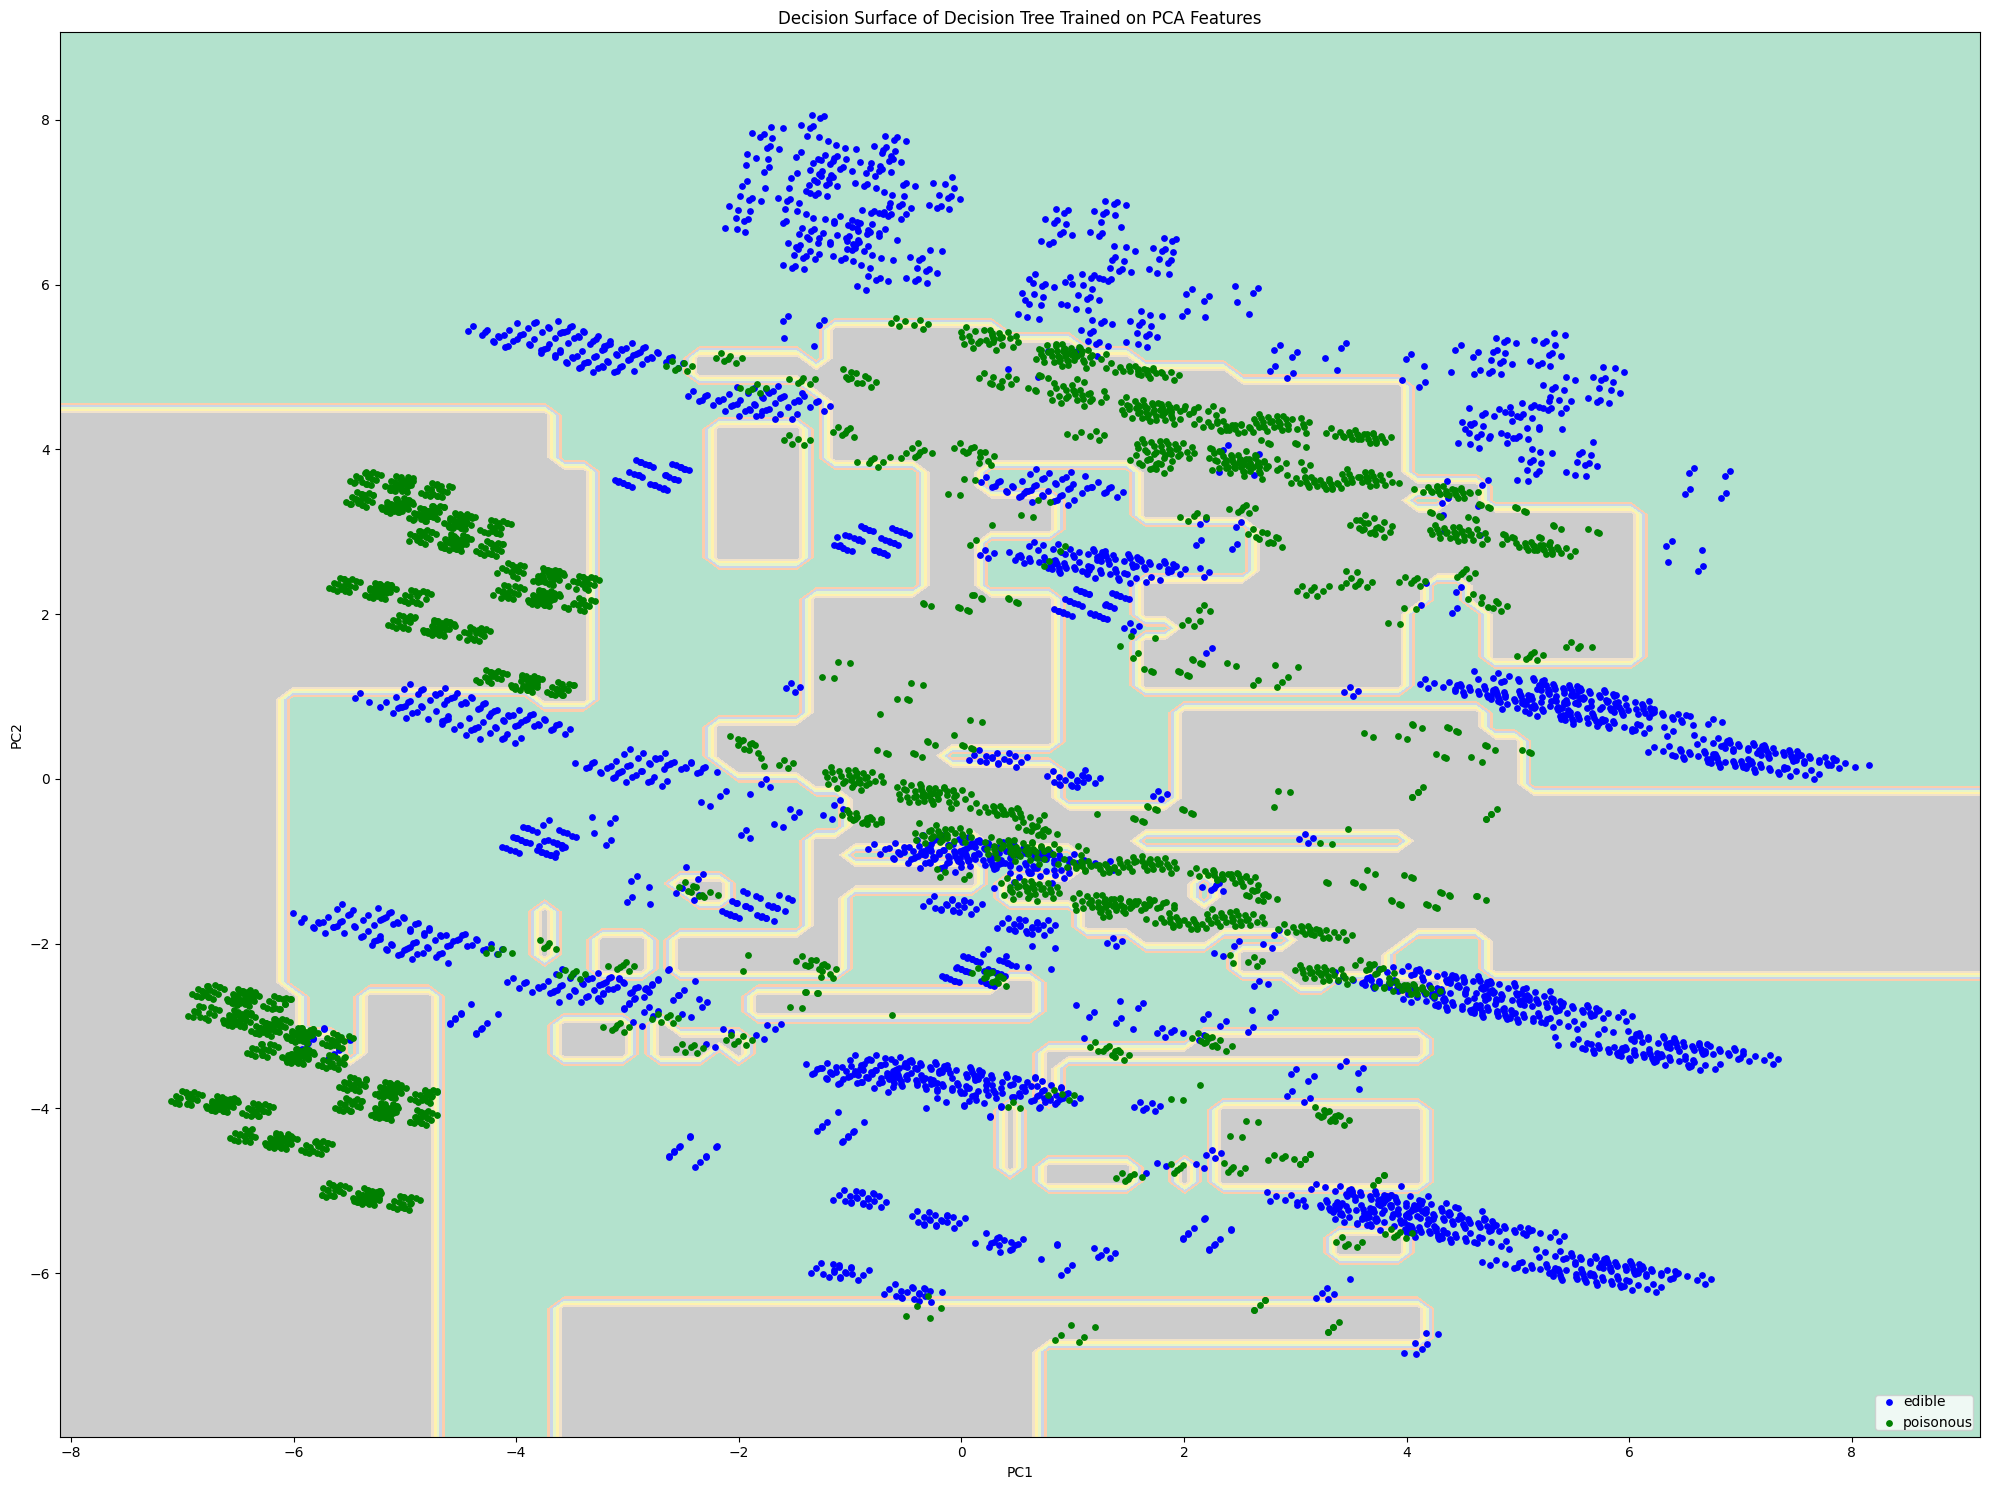

In [ ]:
n_classes = 2
plot_colors = "bg"
plot_step = 0.02

feature_names = ['PC1', 'PC2']

X_pair = x_train[:, [0, 1]]
y_pair = y_train

clf_pair = DecisionTreeClassifier().fit(X_pair, y_pair)

fig, ax = plt.subplots(figsize=(20, 15))

DecisionBoundaryDisplay.from_estimator(
    clf_pair,
    X_pair,
    cmap=plt.cm.Pastel2,
    response_method="predict",
    ax=ax,
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)

for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y_pair == i)
    ax.scatter(
        X_pair[idx, 0],
        X_pair[idx, 1],
        c=color,
        label=label_encoder.inverse_transform([i])[0],
        s=15,
    )

ax.set_title("Decision Boundary of Decision Tree Trained on PCA Features")
ax.legend(loc="lower right", borderpad=0, handletextpad=0)

plt.tight_layout()
plt.show()

**Decision Boundary Visualization (Extra Tree)**

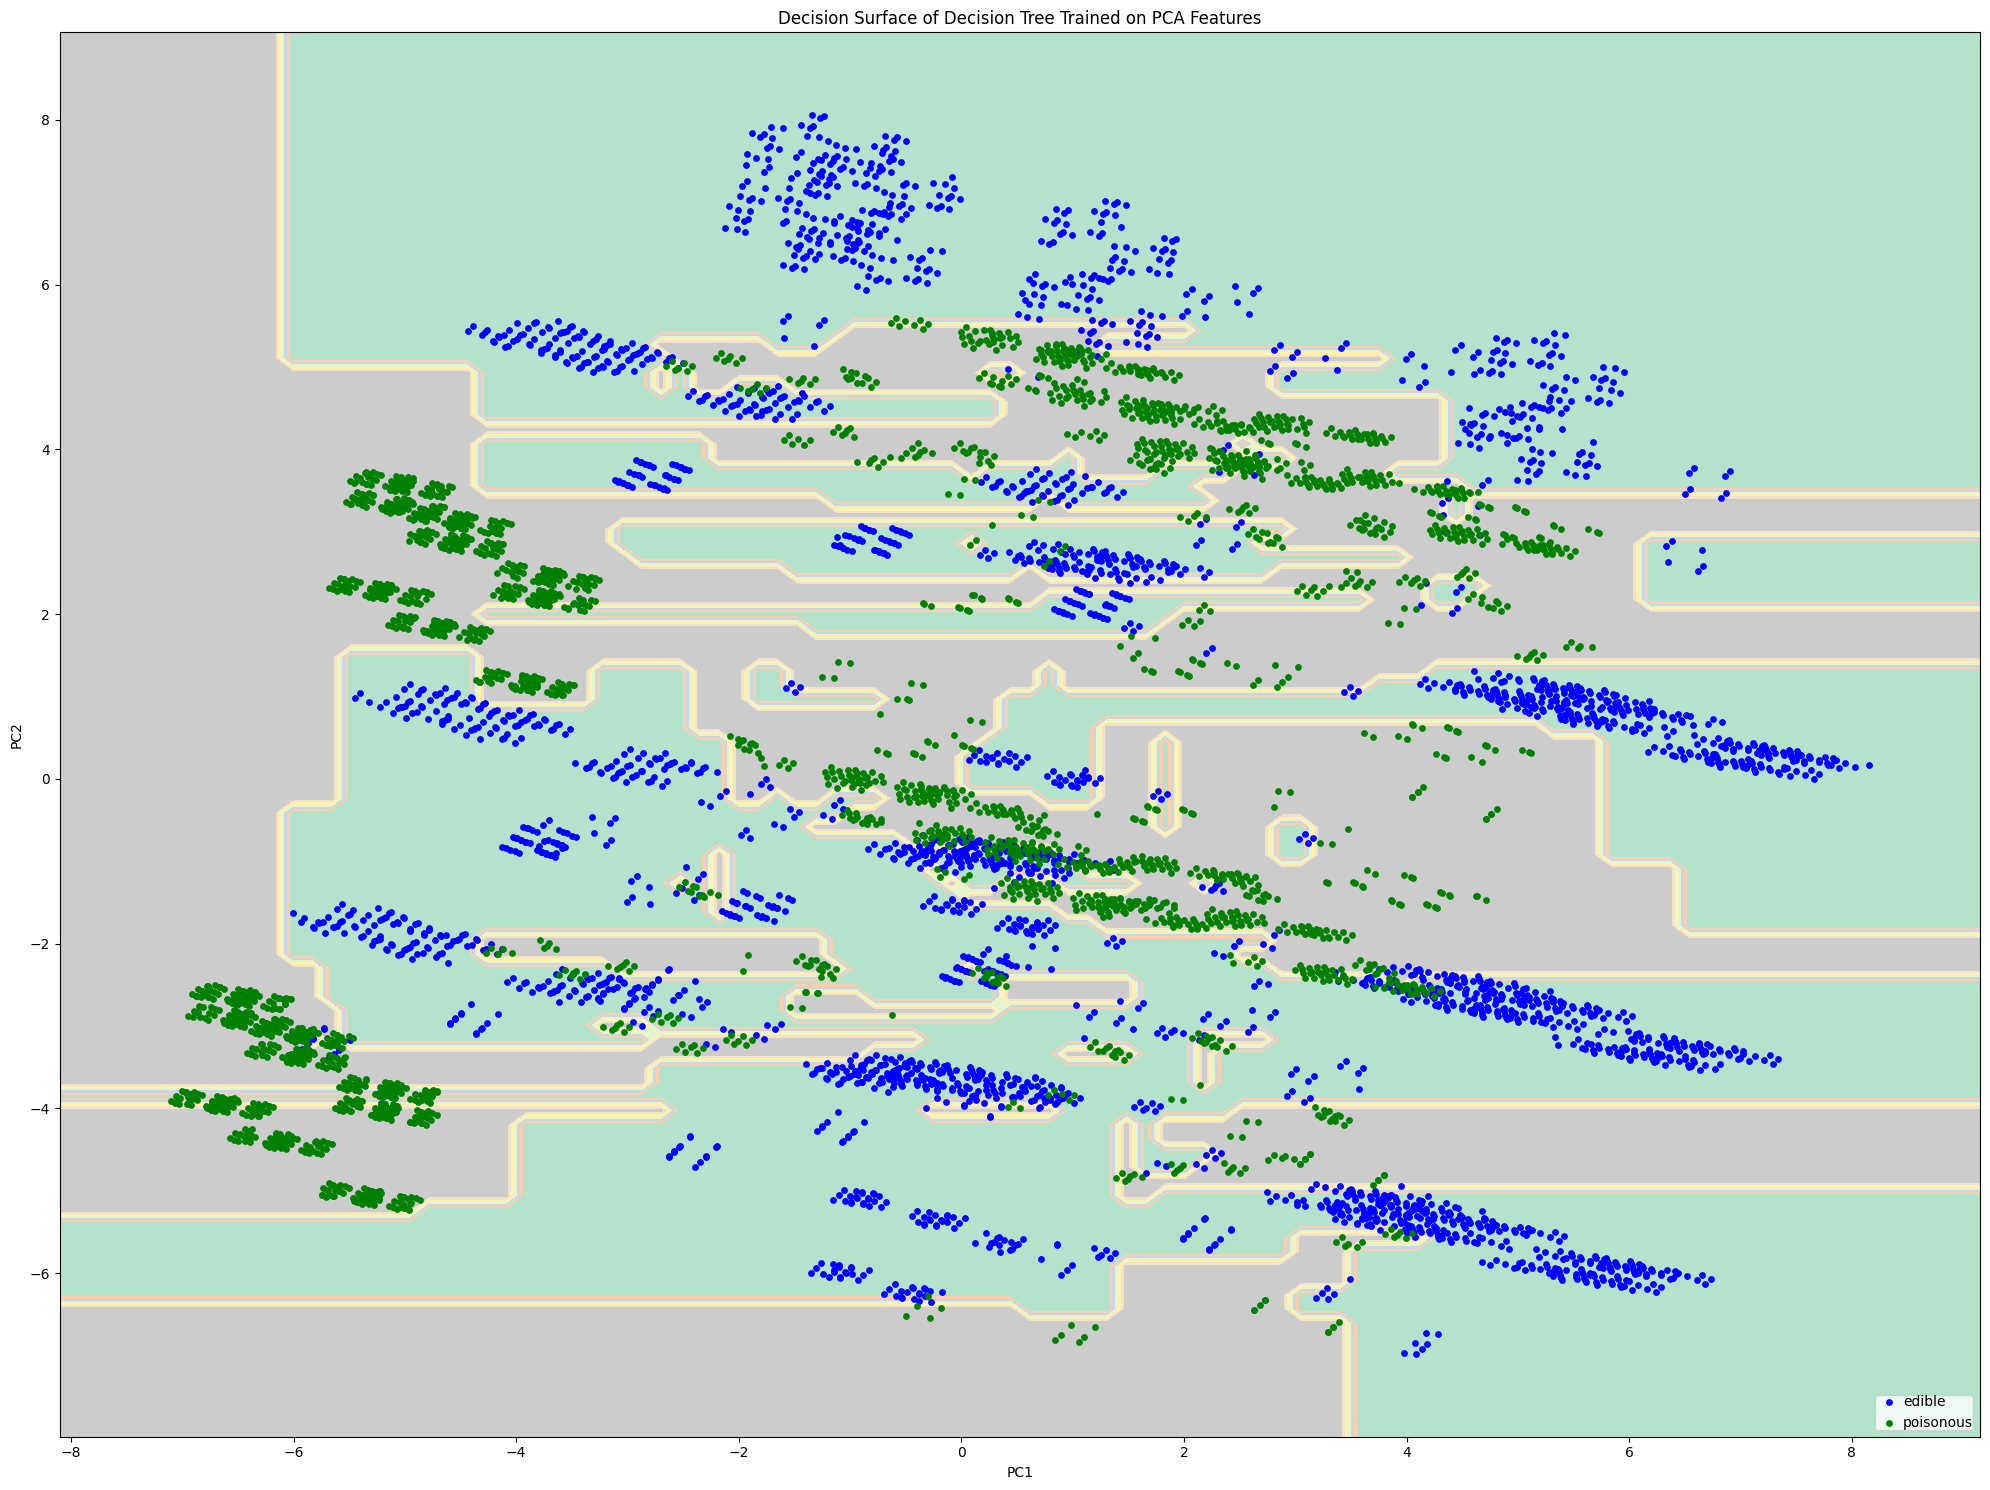

In [ ]:
n_classes = 2
plot_colors = "bg"
plot_step = 0.02

feature_names = ['PC1', 'PC2']

X_pair = x_train[:, [0, 1]]
y_pair = y_train

clf_pair = ExtraTreeClassifier().fit(X_pair, y_pair)

fig, ax = plt.subplots(figsize=(20, 15))

DecisionBoundaryDisplay.from_estimator(
    clf_pair,
    X_pair,
    cmap=plt.cm.Pastel2,
    response_method="predict",
    ax=ax,
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)

for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y_pair == i)
    ax.scatter(
        X_pair[idx, 0],
        X_pair[idx, 1],
        c=color,
        label=label_encoder.inverse_transform([i])[0],
        s=15,
    )

ax.set_title("Decision Surface of Extra Tree Trained on PCA Features")
ax.legend(loc="lower right", borderpad=0, handletextpad=0)

plt.tight_layout()
plt.show()

**Decision Boundary Analysis (Decision Tree vs. Extra Tree)**

**I. Decision Boundaries and Tree Structure**

The visualization you are generating shows the model's predicted regions in a two-dimensional space. The shape and complexity of these regions reveal the fundamental differences between Decision Trees and Extra Trees.

**Decision Boundary Definition**

A Decision Boundary (or Decision Surface in higher dimensions) is the theoretical hyperplane in the feature space where a classifier switches its prediction from one class to another.

Interpretation: For any point on one side of the boundary, the model predicts Class A (e.g., "edible"). For any point on the other side, it predicts Class B (e.g., "poisonous").

**Tree Decision Surface**

For a single Decision Tree Classifier (DTC) or Extra Tree Classifier (ETC) that uses axis-parallel splits (tests on a single feature at a time), the decision boundaries have a distinct, rigid characteristic:

- **Piecewise Linear and Orthogonal:** The boundary is composed of lines (in 2D) or planes (in 3D) that are always parallel to the axes. This results in the feature space being divided into a set of non-overlapping rectangular regions.
- **Visualization Insight:** The code plots this exact structure. The light green and gray regions in your image are the rectangular leaf nodes of the tree, and the boundaries between them represent the split thresholds determined by the classifier.
- **Overfitting Clues:** Highly irregular, fragmented, or "island-like" regions that tightly enclose individual data points often indicate overfitting. The model is attempting to perfectly classify every training sample, including noisy ones, which harms its ability to generalize to new data.

II. Dimensionality Reduction (PCA)The decision boundaries are plotted using the first two principal components (PC1 and PC2), not the original 22 categorical features.

**1. Principal Component Analysis (PCA)**

PCA is an unsupervised linear dimensionality reduction technique. Its purpose is to transform a large set of correlated variables into a smaller set of uncorrelated variables called Principal Components (PCs).

- **Maximum Variance:** The first principal component (PC1) is chosen to maximize the variance of the data projected onto it. PC2 is chosen orthogonally to PC1, maximizing the remaining variance, and so on.
- **Purpose in Visualization:** The code uses PCA to project the high-dimensional mushroom data onto a 2D plane ($\text{PC1}$ vs. $\text{PC2}$). This allows us to visualize the class separation and the resulting decision surface in a compact, interpretable way that retains most of the original information's variance.

**2. Interpretation of the PCA Plot**

The horizontal and vertical axes ($\text{PC1}$ and $\text{PC2}$) are not the original features (like odor or habitat) but linear combinations of those features.The data points (blue for edible, green for poisonous) are clustered in the space. The effectiveness of the classifier is seen in how well its piecewise rectangular boundary cleanly separates the blue and green clusters.

**III. Comparing DTC and ETC Decision Surfaces**

Although the code used a single Decision Tree Classifier (DecisionTreeClassifier().fit(X_pair, y_pair)), the principles for an Extra Tree Classifier (ETC) are similar in this 2D visualization:

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-hs1k{border-color:inherit;color:#1B1C1D;font-size:100%;font-weight:bold;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-hs1k">Classifier</th>
    <th class="tg-7zrl">Behavior on Decision Surface</th>
    <th class="tg-0lax">Theoretical Implication</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Decision Tree (DTC)</td>
    <td class="tg-7zrl">Tends to create very intricate, highly tailored rectangular regions that fit the training data clusters precisely.</td>
    <td class="tg-0lax">High potential for low bias (fits training data well) but high variance (overfitting).</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Extra Tree (ETC)</td>
    <td class="tg-7zrl">In a 2D plot, the boundaries would also be rectangular, but they might be slightly simpler or less optimally aligned with the clusters due to the random split threshold selection.</td>
    <td class="tg-0lax">Prioritizes low variance and is less prone to overfitting, often resulting in slightly smoother, more generalized regions.</td>
  </tr>
</tbody>
</table>

Prioritizes low variance and is less prone to overfitting, often resulting in slightly smoother, more generalized regions.Visualizing these boundaries is a crucial step in machine learning model evaluation because it allows the analyst to directly observe the model's generalization capacity before moving on to numerical metrics.

**Algorithm Decision**

To gain insights into the internal logic of the decision tree models, understand which features are most influential, and identify potential overfitting (e.g., very deep trees with many small leaves). These sections use plot_tree to visualize the entire structure of the DecisionTreeClassifier and ExtraTreeClassifier trained on the original, non-PCA-transformed data (x_train_nopca).

* **Tree Structure**: This visualization shows the nodes, splits, and leaves of the decision tree. Each node displays the feature and threshold used for splitting, the Gini impurity/entropy, the number of samples at that node, and the class distribution.

* **Interpretability**: Decision trees are often called "white-box" models because their decision-making process is highly interpretable. By visualizing the tree, one can understand the exact rules the model uses to classify instances.

* **Feature Importance**: The features that appear higher up in the tree (closer to the root) are generally more important for classification.

**Decision Trees Algorithm Decision**

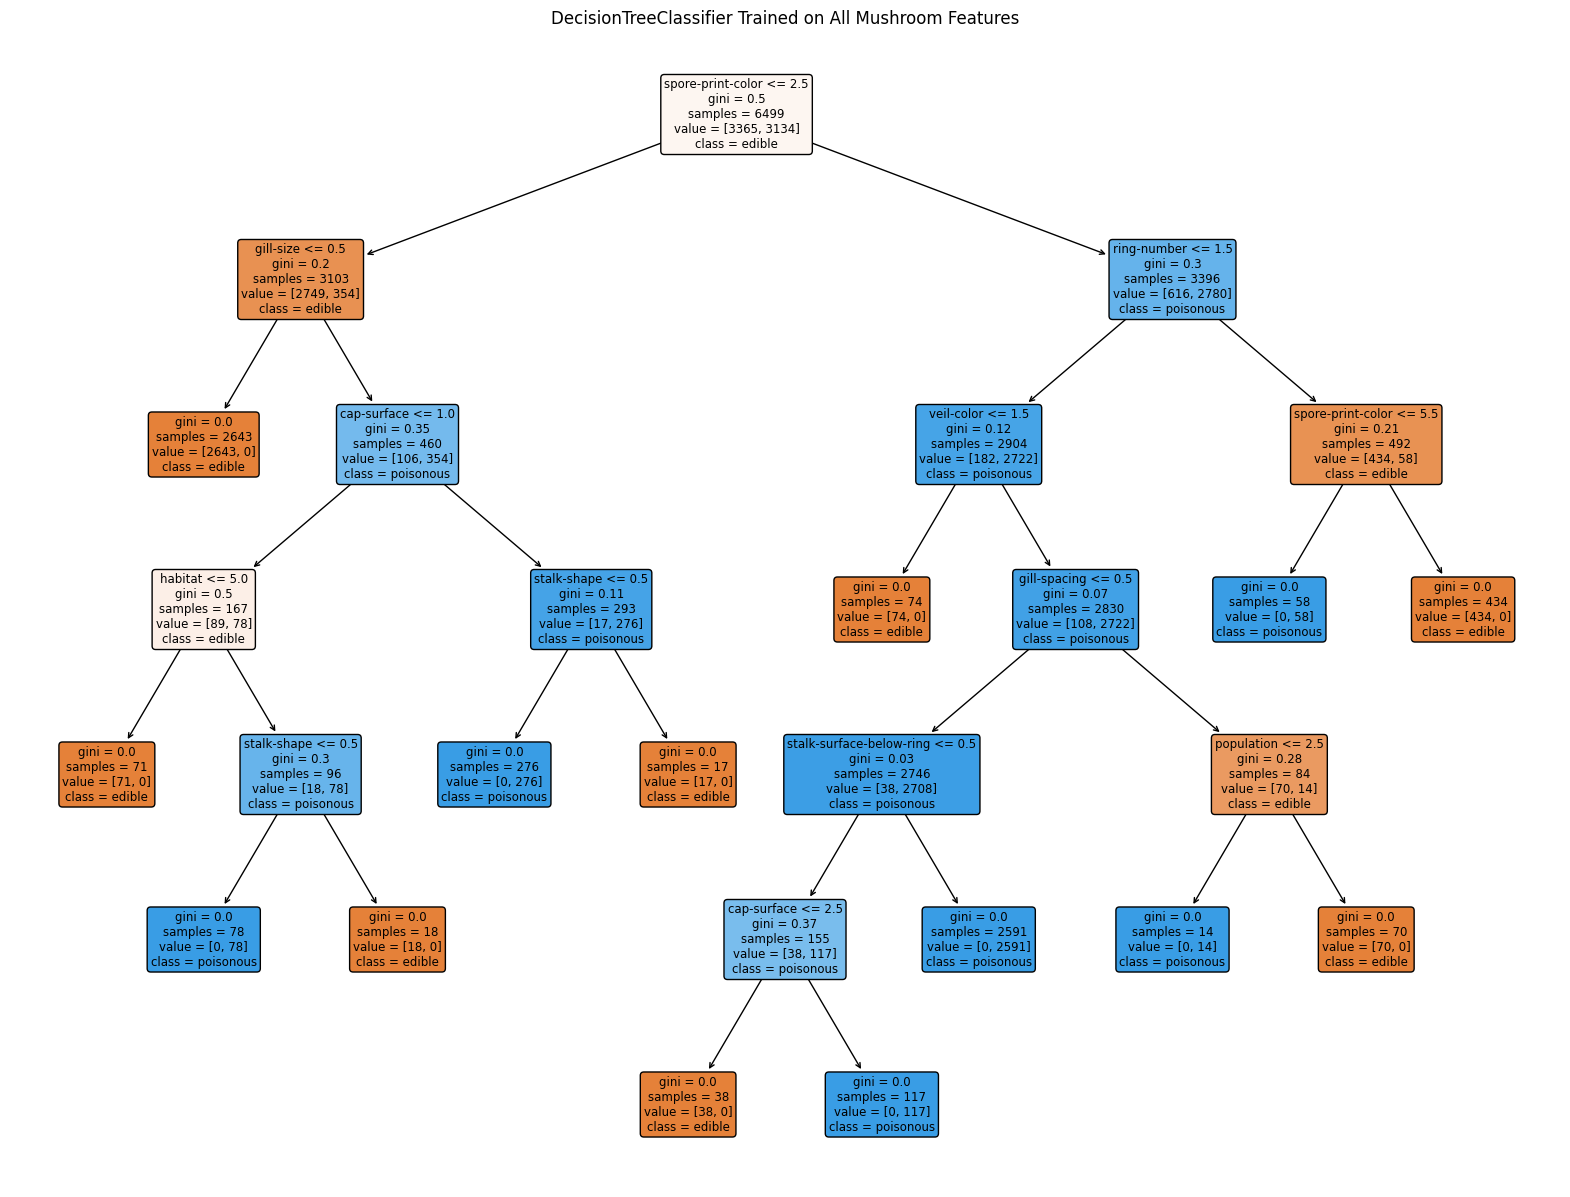

In [ ]:
clf = DecisionTreeClassifier()

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"DecisionTreeClassifier Trained on All Mushroom Features")

plt.show()

**Extra Trees Algorithm Decision**

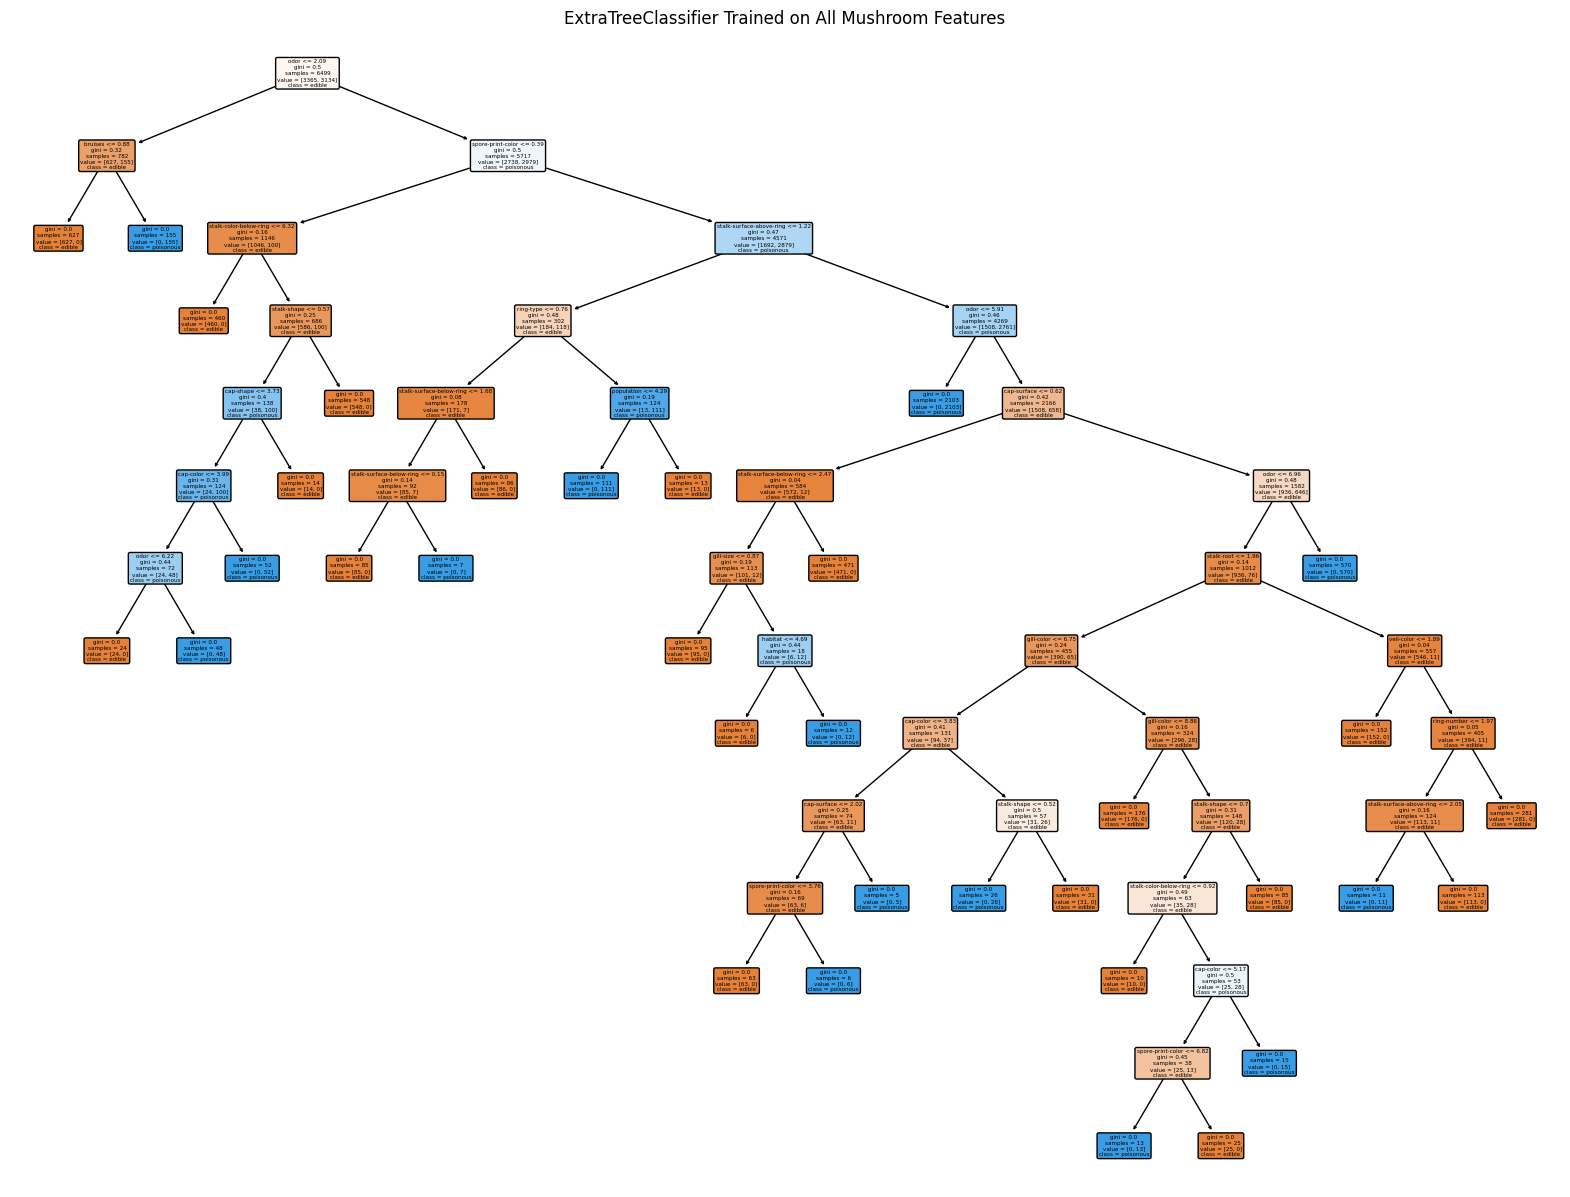

In [75]:
clf = ExtraTreeClassifier()

# Train the classifier
clf.fit(x_train_nopca, y_train)

# Create a figure for the tree visualization
plt.figure(figsize=(20, 15))

# Plot the decision tree
plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  # Use label_encoder.classes_
        rounded=True,
        proportion=False,
        precision=2,
)

# Set title
plt.title(f"ExtraTreeClassifier Trained on All Mushroom Features")

# Show the plot
plt.show()

**Gini Index, Entropy, and Log Loss (Decision Tree and Extra Tree)**

These sections repeat the cross-validation and tree plotting for DecisionTreeClassifier and ExtraTreeClassifier, but explicitly set the criterion parameter to 'gini', 'entropy', and 'log_loss' respectively.

**Gini Index (Decision Tree and Extra Tree)**

To explore how different impurity measures affect the tree's structure and the model's performance. Gini impurity is a common and often effective choice. The criterion='gini' parameter specifies that the Gini impurity will be used as the function to measure the quality of a split.

* **Gini Impurity**: A measure of impurity or disorder used in decision trees. A Gini impurity of 0 means all samples at a node belong to the same class (perfect purity). A higher Gini impurity indicates a more mixed distribution of classes. The algorithm aims to find splits that minimize Gini impurity in the child nodes.

* **Formula**: A Gini score of 0 means perfect purity. Gini impurity is calculated as:

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} (P_i)^2$$

where $P_i$ is the probability of class $i$ at node $t$.

In [ ]:
ml_models = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(criterion='gini')),
    ("ExtraTreeClassifier", ExtraTreeClassifier(criterion='gini')),
]

for model in ml_models:
    print(model[0]+": ")
    model[1].fit(x_train, y_train)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model[1], x_train, y_train, cv=skf, scoring='accuracy')
    print("\tStratified K-Fold Cross-Validation:", cv_scores)
    print('-'*100)
    print(f'\tAverage Stratified K-Fold Cross-Validation: {cv_scores.mean()}')
    print('-'*100)

DecisionTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.94615385 0.93846154 0.92461538 0.92615385 0.92769231 0.94307692
 0.93076923 0.94153846 0.94       0.93528505]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9353746592390658
----------------------------------------------------------------------------------------------------
ExtraTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.92       0.90923077 0.91076923 0.93076923 0.89692308 0.90307692
 0.90923077 0.90307692 0.89846154 0.90292758]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9084466042432144
----------------------------------------------------------------------------------------------------


**Algorithm Decision with Gini Index (Decision Tree)**

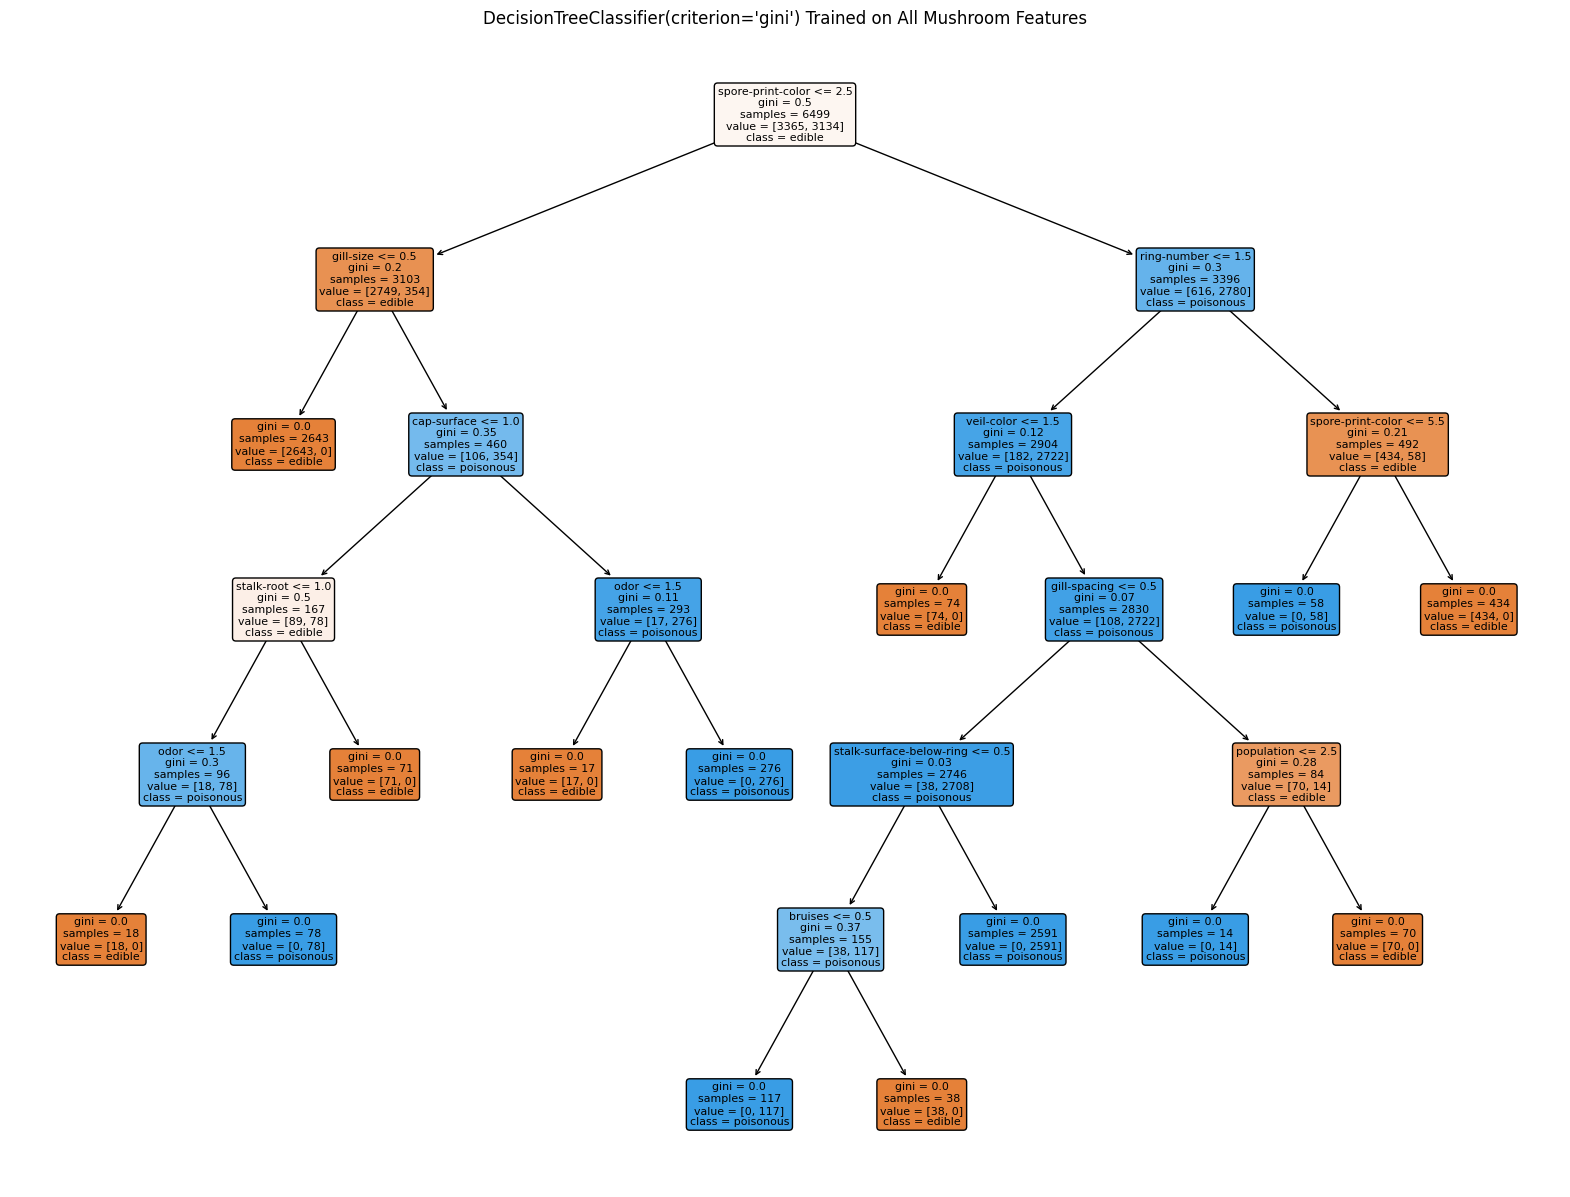

In [ ]:
clf = DecisionTreeClassifier(criterion='gini')

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"DecisionTreeClassifier(criterion='gini') Trained on All Mushroom Features")

plt.show()

**Algorithm Decision with Gini Index (Extra Tree)**

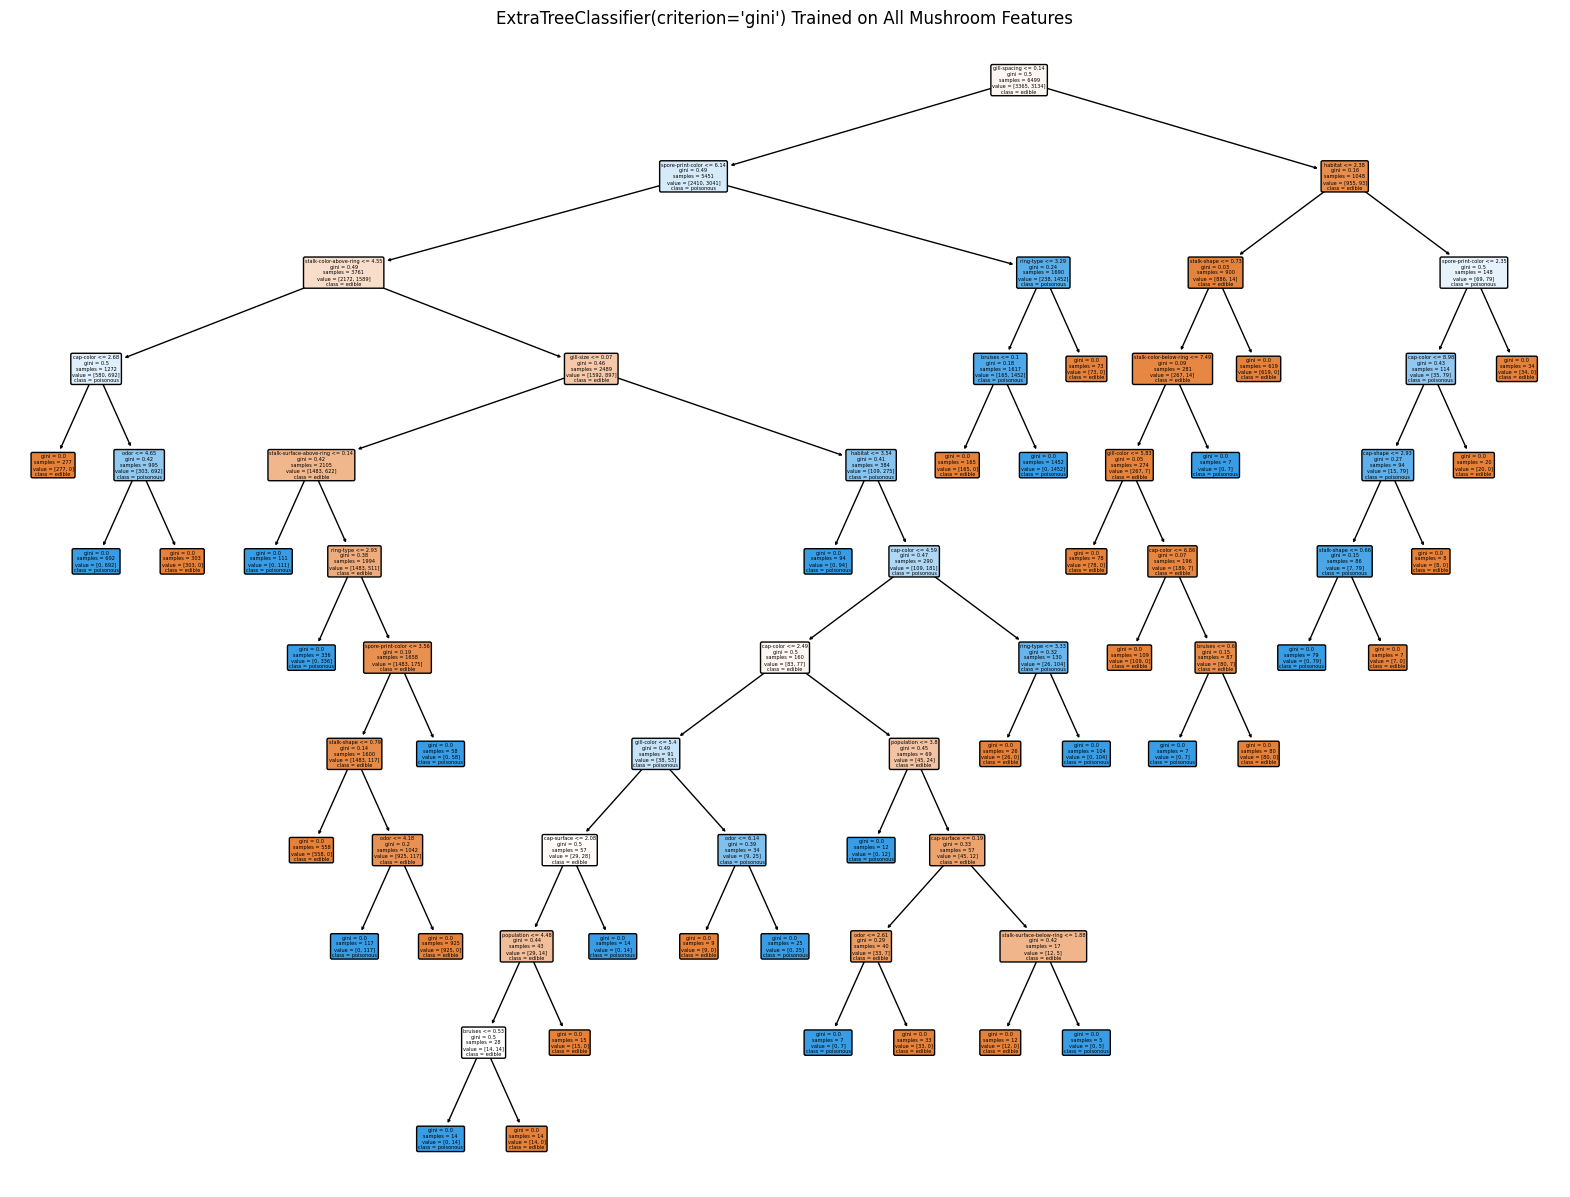

In [ ]:
clf = ExtraTreeClassifier(criterion='gini')

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"ExtraTreeClassifier(criterion='gini') Trained on All Mushroom Features")

plt.show()

**Entropy (Decision Tree and Extra Tree)**

To compare the performance and tree structure when using entropy as the splitting criterion. Both Gini and Entropy are popular choices, and their effectiveness can vary depending on the dataset.The criterion='entropy' parameter specifies that information gain (based on entropy) will be used to measure the quality of a split.

* **Entropy**: Entropy measures the degree of randomness or uncertainty in the node's class distribution. Maximizing information gain is equivalent to minimizing entropy. Higher entropy means more disorder. The goal of a decision tree is to reduce entropy as much as possible at each split. 

* **Information Gain**: The reduction in entropy achieved by splitting a node. The algorithm chooses the split that maximizes information gain.

* **Formula**: Entropy is calculated as

$$\text{Entropy}(t) = - \sum_{i=1}^{C} P_i \log_2(P_i)$$

In [ ]:
ml_models = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(criterion='entropy')),
    ("ExtraTreeClassifier", ExtraTreeClassifier(criterion='entropy')),
]

for model in ml_models:
    print(model[0]+": ")
    model[1].fit(x_train, y_train) # Use PCA transformed data
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Use StratifiedKFold
    cv_scores = cross_val_score(model[1], x_train, y_train, cv=skf, scoring='accuracy') # Use StratifiedKFold
    print("\tStratified K-Fold Cross-Validation:", cv_scores)
    print('-'*100)
    print(f'\tAverage Stratified K-Fold Cross-Validation: {cv_scores.mean()}')
    print('-'*100)

DecisionTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.94       0.94461538 0.93230769 0.93384615 0.93230769 0.93384615
 0.94461538 0.94       0.92461538 0.93374422]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9359898068033662
----------------------------------------------------------------------------------------------------
ExtraTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.93538462 0.91846154 0.92153846 0.92       0.91692308 0.90923077
 0.91076923 0.91846154 0.89846154 0.90909091]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9158321678321677
----------------------------------------------------------------------------------------------------


**Algorithm Decision with Entropy (Decision Tree)**

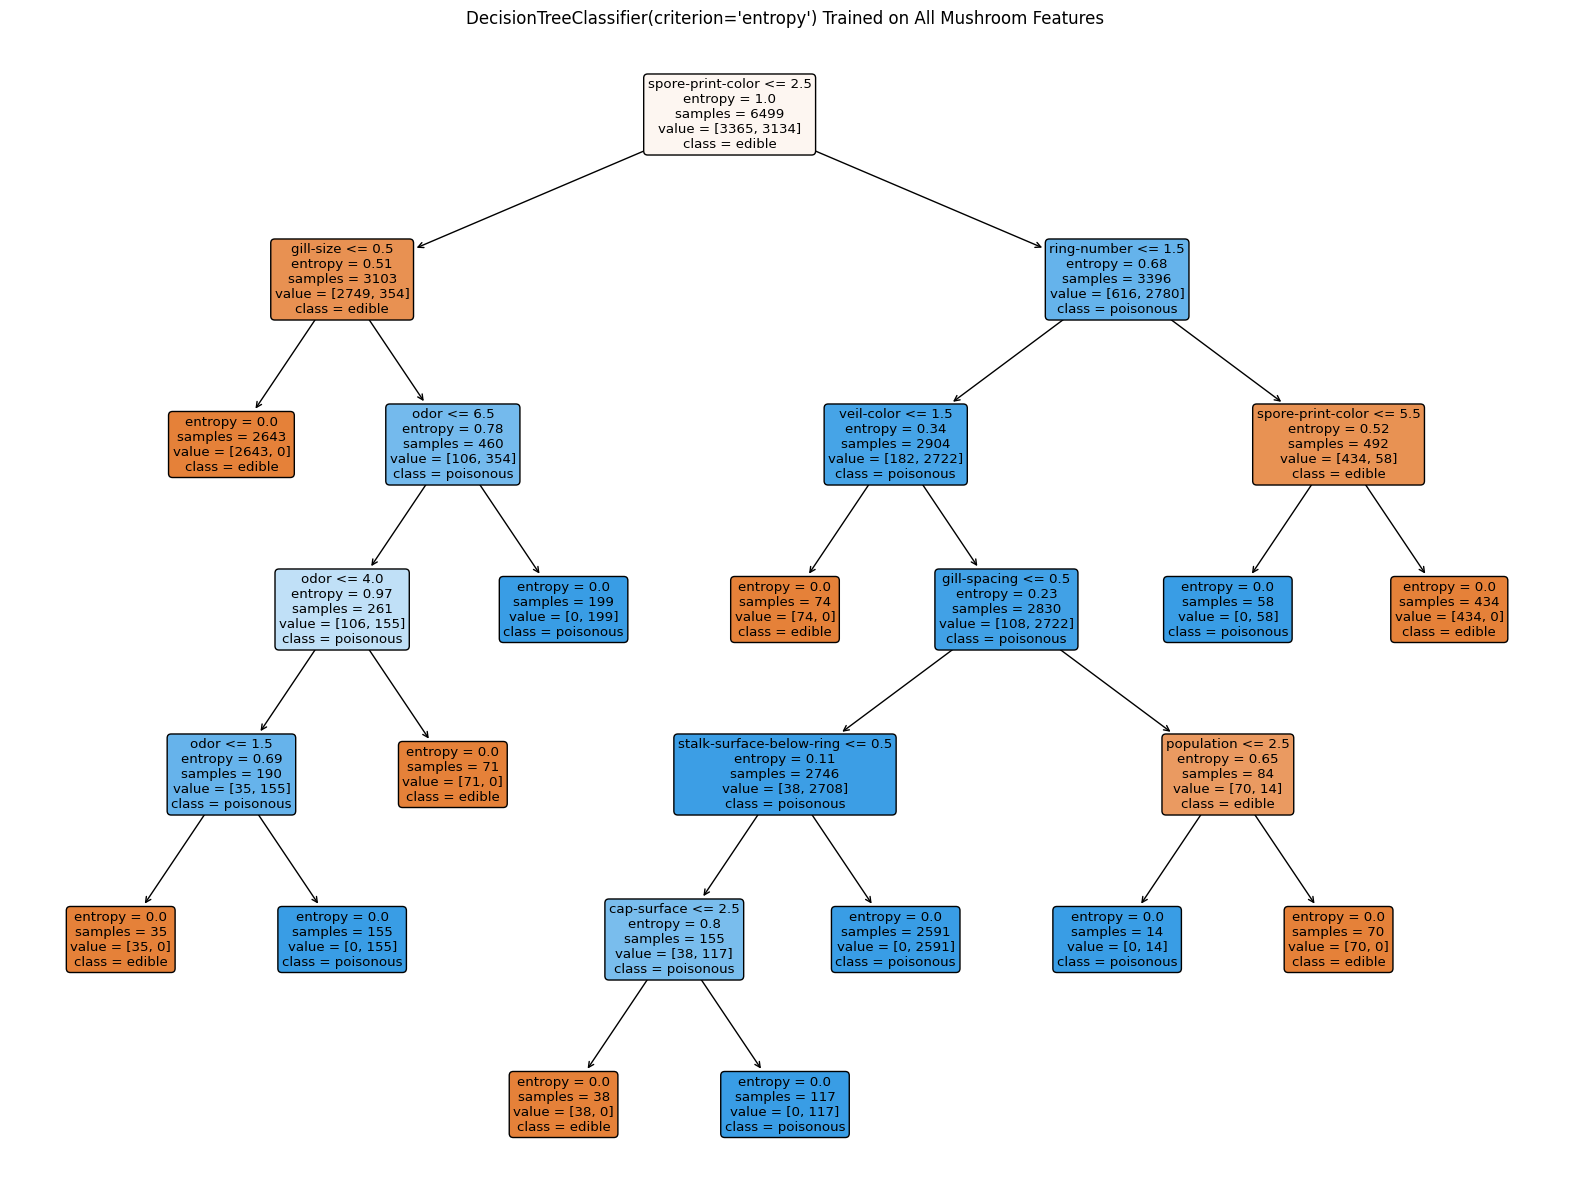

In [ ]:
clf = DecisionTreeClassifier(criterion='entropy')

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  # Use label_encoder.classes_
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"DecisionTreeClassifier(criterion='entropy') Trained on All Mushroom Features")

plt.show()

**Algorithm Decision with Entropy (Extra Tree)**

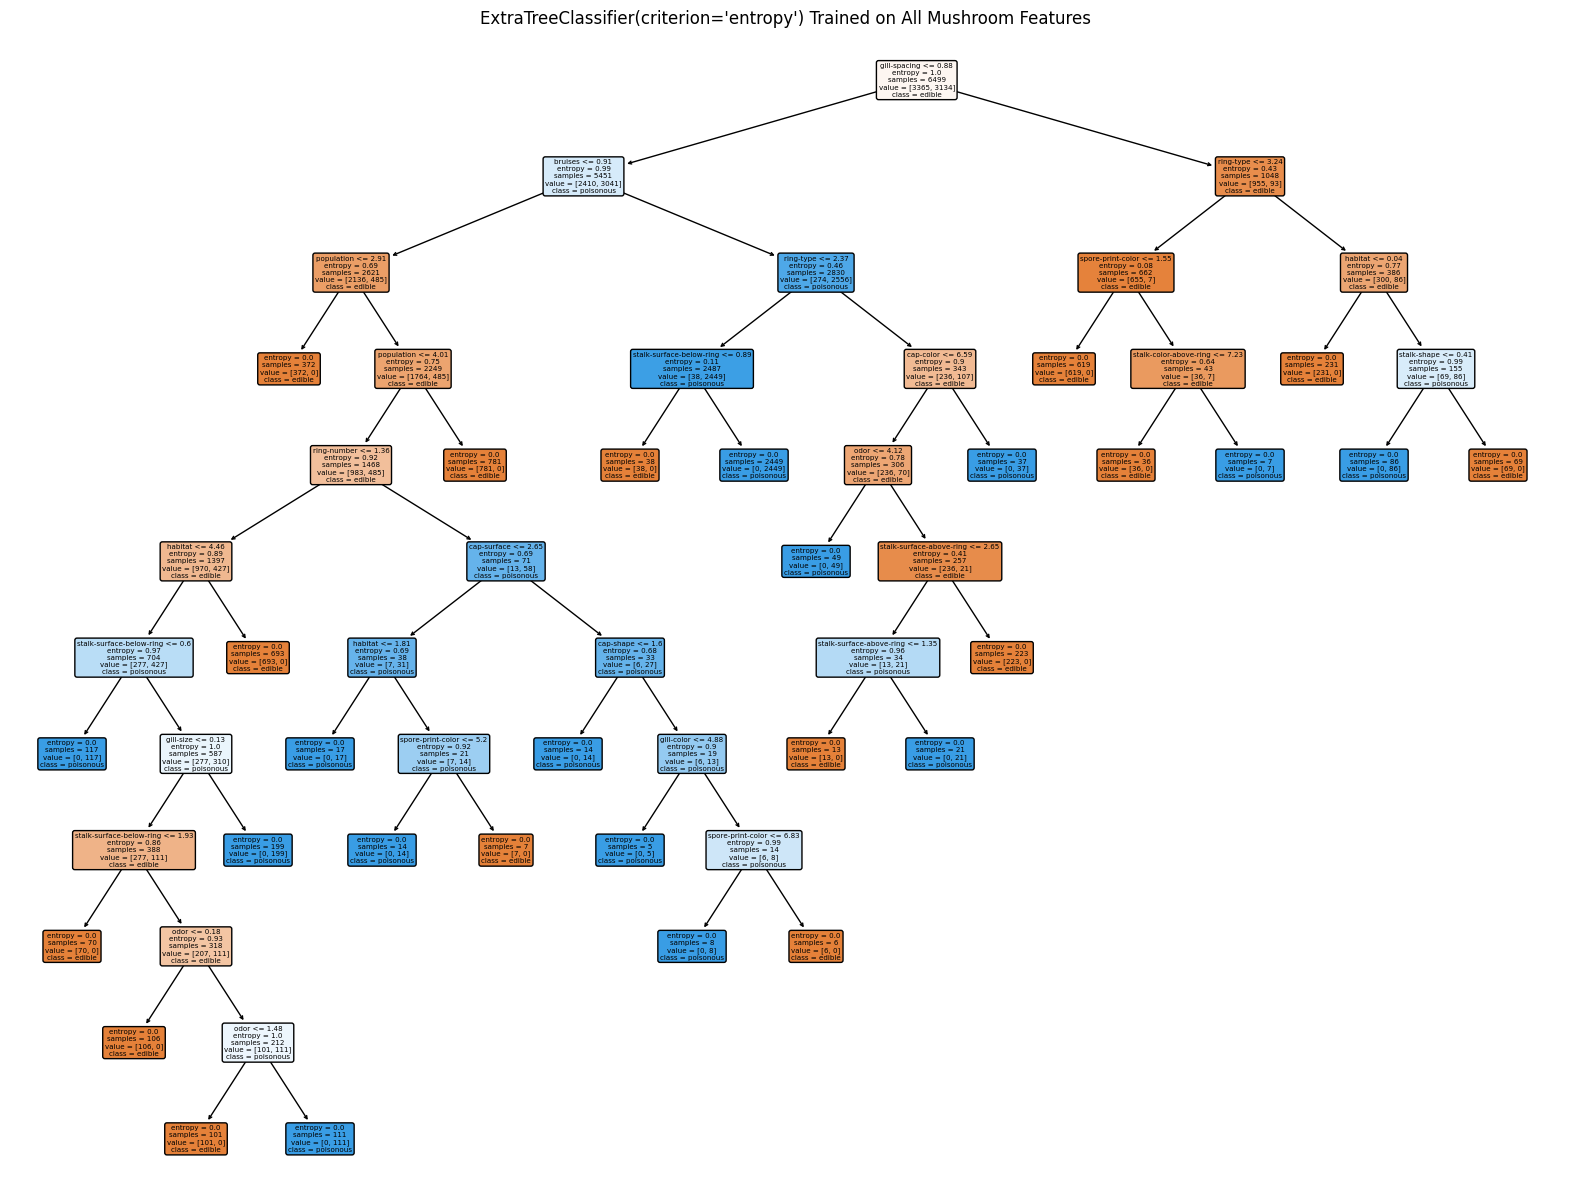

In [81]:
clf = ExtraTreeClassifier(criterion='entropy')

# Train the classifier
clf.fit(x_train_nopca, y_train)

# Create a figure for the tree visualization
plt.figure(figsize=(20, 15))

# Plot the decision tree
plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),  # Use label_encoder.classes_
        rounded=True,
        proportion=False,
        precision=2,
)

# Set title
plt.title(f"ExtraTreeClassifier(criterion='entropy') Trained on All Mushroom Features")

# Show the plot
plt.show()

**Log Loss (Decision Tree and Extra Tree)**

To evaluate the impact of using log loss as a splitting criterion, which is often used in models that output probabilities. The criterion='log_loss' parameter specifies that log loss (also known as cross-entropy) will be used as the function to measure the quality of a split.

* **Log Loss (Cross-Entropy)**: A measure of the performance of a classification model where the prediction output is a probability value between 0 and 1. It penalizes false classifications. Minimizing log loss is equivalent to maximizing the likelihood of the true label.

In [ ]:
ml_models = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(criterion='log_loss')),
    ("ExtraTreeClassifier", ExtraTreeClassifier(criterion='log_loss')),
]

for model in ml_models:
    print(model[0]+": ")
    model[1].fit(x_train, y_train) 
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
    cv_scores = cross_val_score(model[1], x_train, y_train, cv=skf, scoring='accuracy')
    print("\tStratified K-Fold Cross-Validation:", cv_scores)
    print('-'*100)
    print(f'\tAverage Stratified K-Fold Cross-Validation: {cv_scores.mean()}')
    print('-'*100)

DecisionTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.94769231 0.94769231 0.93230769 0.93076923 0.93538462 0.93076923
 0.94461538 0.94461538 0.92307692 0.93528505]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9372208130852199
----------------------------------------------------------------------------------------------------
ExtraTreeClassifier: 
	Stratified K-Fold Cross-Validation: [0.91692308 0.92461538 0.91846154 0.91384615 0.92       0.90307692
 0.91384615 0.90307692 0.90307692 0.9229584 ]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation: 0.9139881474457745
----------------------------------------------------------------------------------------------------


**Algorithm Decision with Log Loss (Decision Tree)**

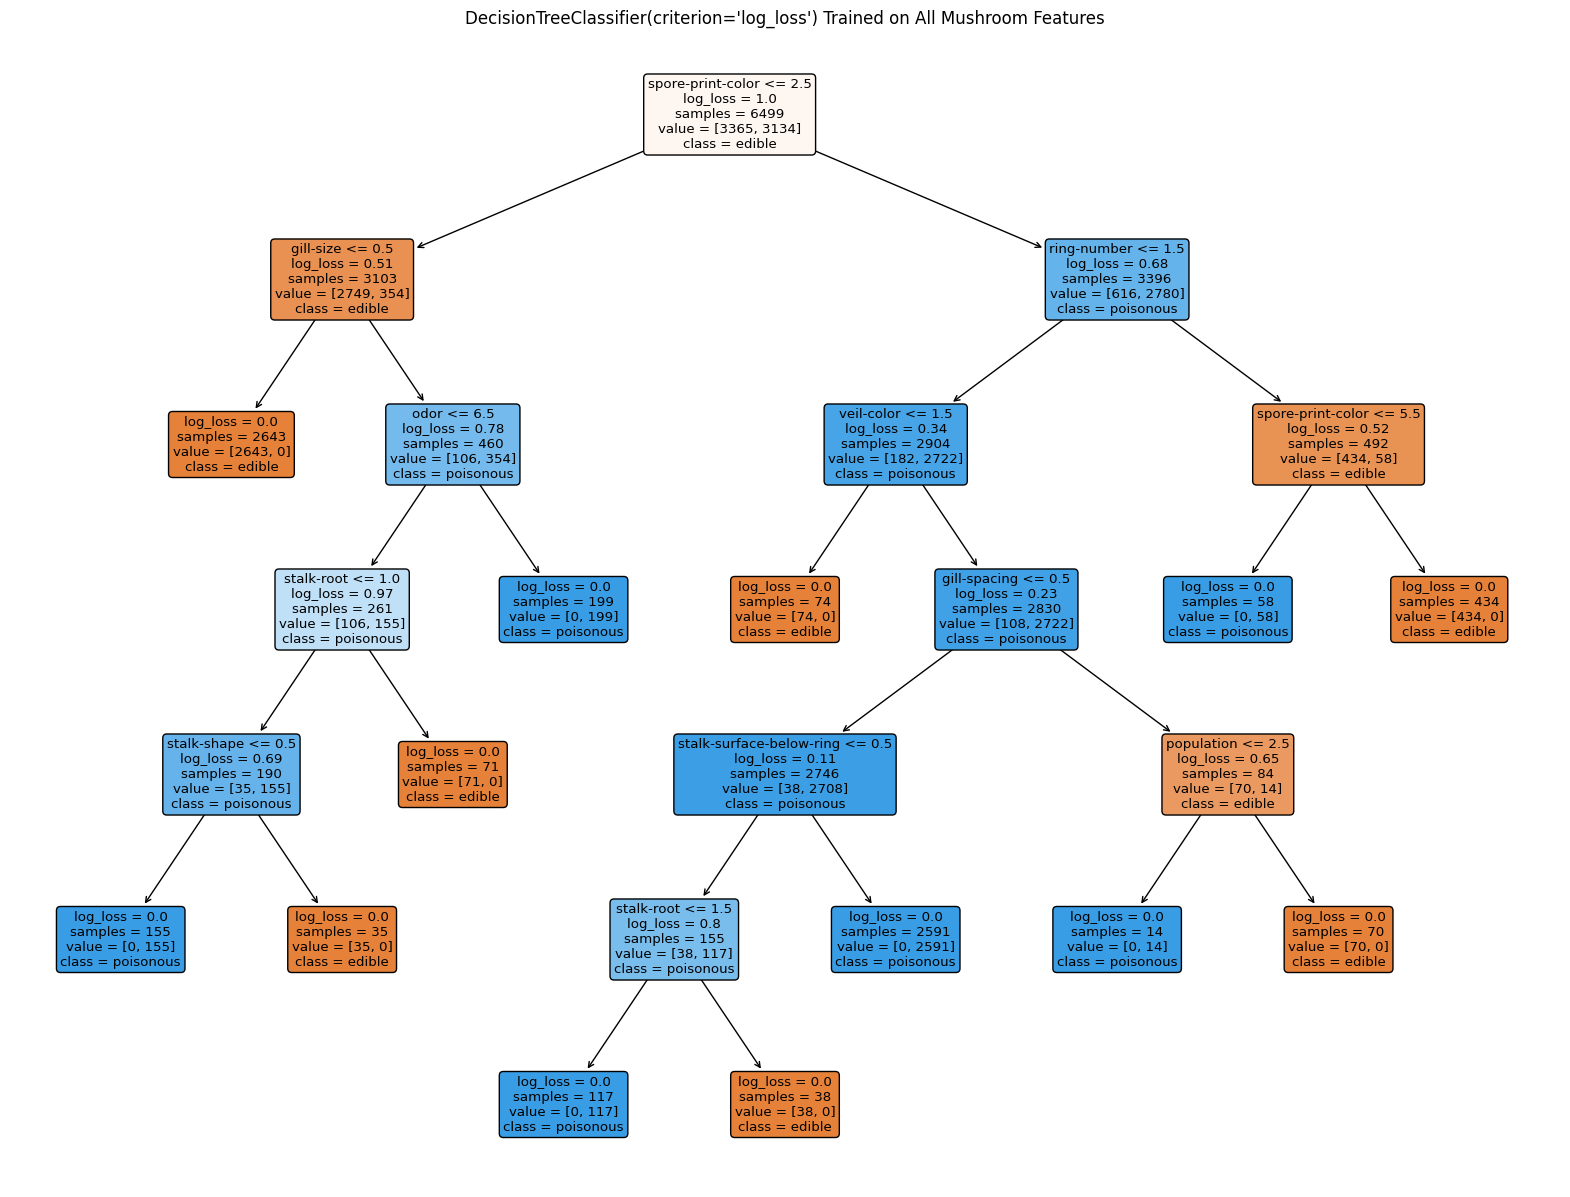

In [ ]:
clf = DecisionTreeClassifier(criterion='log_loss')

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_), 
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"DecisionTreeClassifier(criterion='log_loss') Trained on All Mushroom Features")

plt.show()

**Algorithm Decision with Log Loss (Extra Tree)**

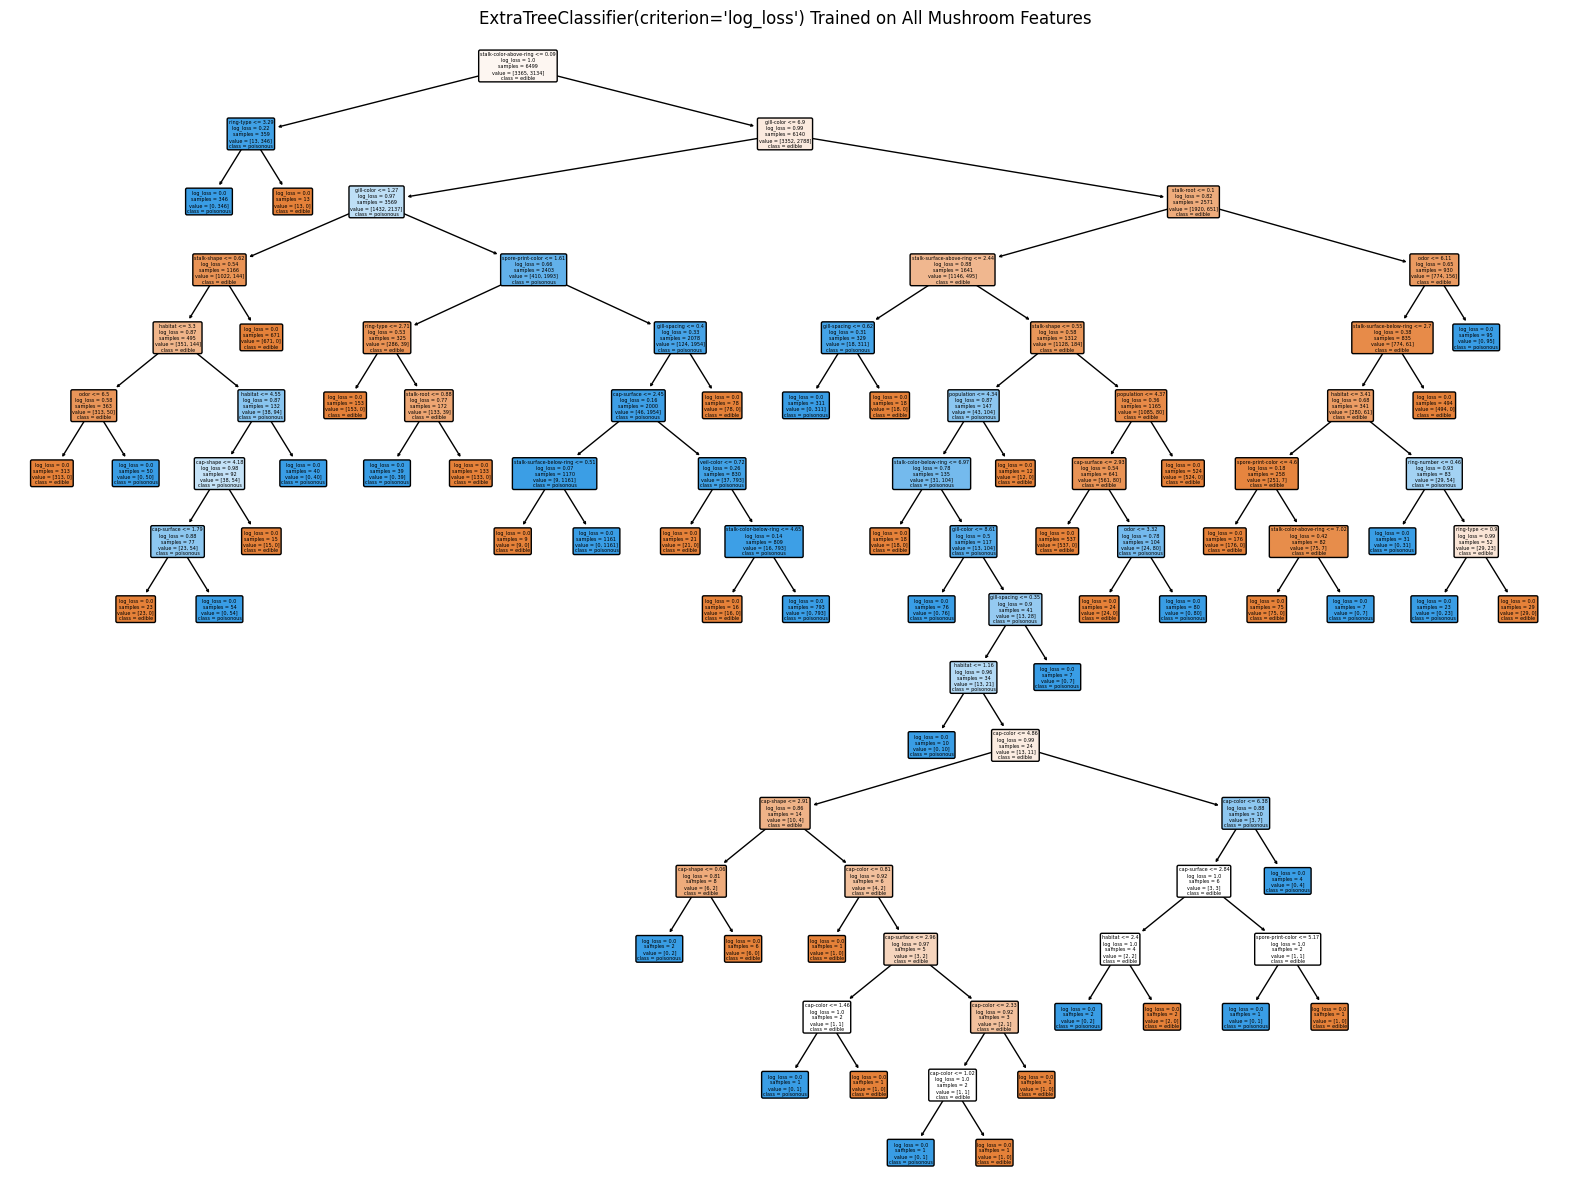

In [ ]:
clf = ExtraTreeClassifier(criterion='log_loss')

clf.fit(x_train_nopca, y_train)

plt.figure(figsize=(20, 15))

plot_tree(
        clf,
        filled=True,
        feature_names=x_train_nopca.columns,
        class_names=list(label_encoder.classes_),
        rounded=True,
        proportion=False,
        precision=2,
)

plt.title(f"ExtraTreeClassifier(criterion='log_loss') Trained on All Mushroom Features")

plt.show()

**Post Tree Pruning (Cost Complexity Pruning)**

Pruning is a technique used to reduce the size of decision trees by removing sections of the tree that provide little power to classify instances. This helps to reduce overfitting and improve the model's generalization.

This section explores cost-complexity pruning (CCP), also known as weakest link pruning. It calculates the `ccp_alphas` (effective alphas) and corresponding impurities for different pruned versions of the decision tree. It then plots:

* Total impurity of leaves against effective alpha.

* Number of nodes against alpha.

* Depth of the tree against alpha.

To understand the relationship between the `ccp_alpha` parameter and the complexity and impurity of the pruned decision tree. This analysis helps in selecting an optimal `ccp_alpha` for pruning, which can prevent overfitting and improve the model's generalization performance.

* **Cost-Complexity Pruning (CCP)**: A pruning technique that finds a sequence of optimal subtrees by iteratively removing the weakest links (nodes that contribute the least to reducing impurity). The ccp_alpha parameter controls the trade-off between the complexity of the tree (number of nodes) and its impurity. A higher ccp_alpha results in more pruning and a simpler tree.

* **`ccp_alphas`**: A list of alpha values that define the pruning thresholds. For each alpha, a different pruned tree is obtained.

* **Total Impurity of Leaves**: The sum of the impurities of all leaf nodes in the tree. Pruning aims to find a balance where impurity is low without making the tree overly complex.

* **Number of Nodes and Depth**: These metrics indicate the complexity of the tree. Pruning reduces both the number of nodes and the maximum depth, leading to simpler, more generalized models.

**Cost-Complexity Pruning (CCP) Theory**

Pruning is a technique used to simplify a decision tree, which is necessary because fully grown trees are susceptible to overfitting (achieving near-perfect accuracy on the training data but failing to generalize to new, unseen data). Cost-Complexity Pruning (CCP), also known as Weakest Link Pruning, is a post-pruning method that finds the optimal sequence of pruned subtrees.

**1. The Cost-Complexity Criterion**

CCP works by defining a cost function for every subtree $T$ of the original tree $T_0$. This function balances the tree's error against its complexity.The cost function is defined as:$$R_{\alpha}(T) = R(T) + \alpha \cdot |T|$$Where:$R_{\alpha}(T)$ is the Cost-Complexity of the subtree $T$.$R(T)$ is the Total Impurity of Leaves (or total error) of the subtree $T$ on the training data. This is the metric plotted in your first figure .$|T|$ is the Complexity of the subtree, usually measured by the number of leaf nodes (or total number of nodes). This relates directly to the metrics plotted in your second set of figures .$\alpha$ (alpha) is the Effective Alpha or Complexity Parameter. This parameter controls the penalty assigned to complexity.

**2. How Pruning Works**

The CCP algorithm finds the $\alpha$ values that define the points where a subtree becomes the optimal balance of impurity and complexity.

- Low $\alpha$ (Near Zero): The penalty for complexity is negligible. The algorithm selects the largest, most complex tree, which minimizes $R(T)$ (impurity) but results in high complexity $|T|$. This is the fully-grown tree.
- High $\alpha$: The penalty for complexity dominates. The algorithm chooses the simplest tree (often just the root node), resulting in low complexity $|T|$ but high impurity $R(T)$.
- Optimal $\alpha$: The algorithm generates a sequence of optimal pruned trees by increasing $\alpha$. The final optimal tree is chosen by evaluating the performance of each tree in this sequence against a separate validation set (typically using cross-validation). The chosen $\alpha$ is the one that minimizes the validation error.

**Total Impurity of Leaves VS. Effective Alphas of Pruned Tree (Decision Tree)**

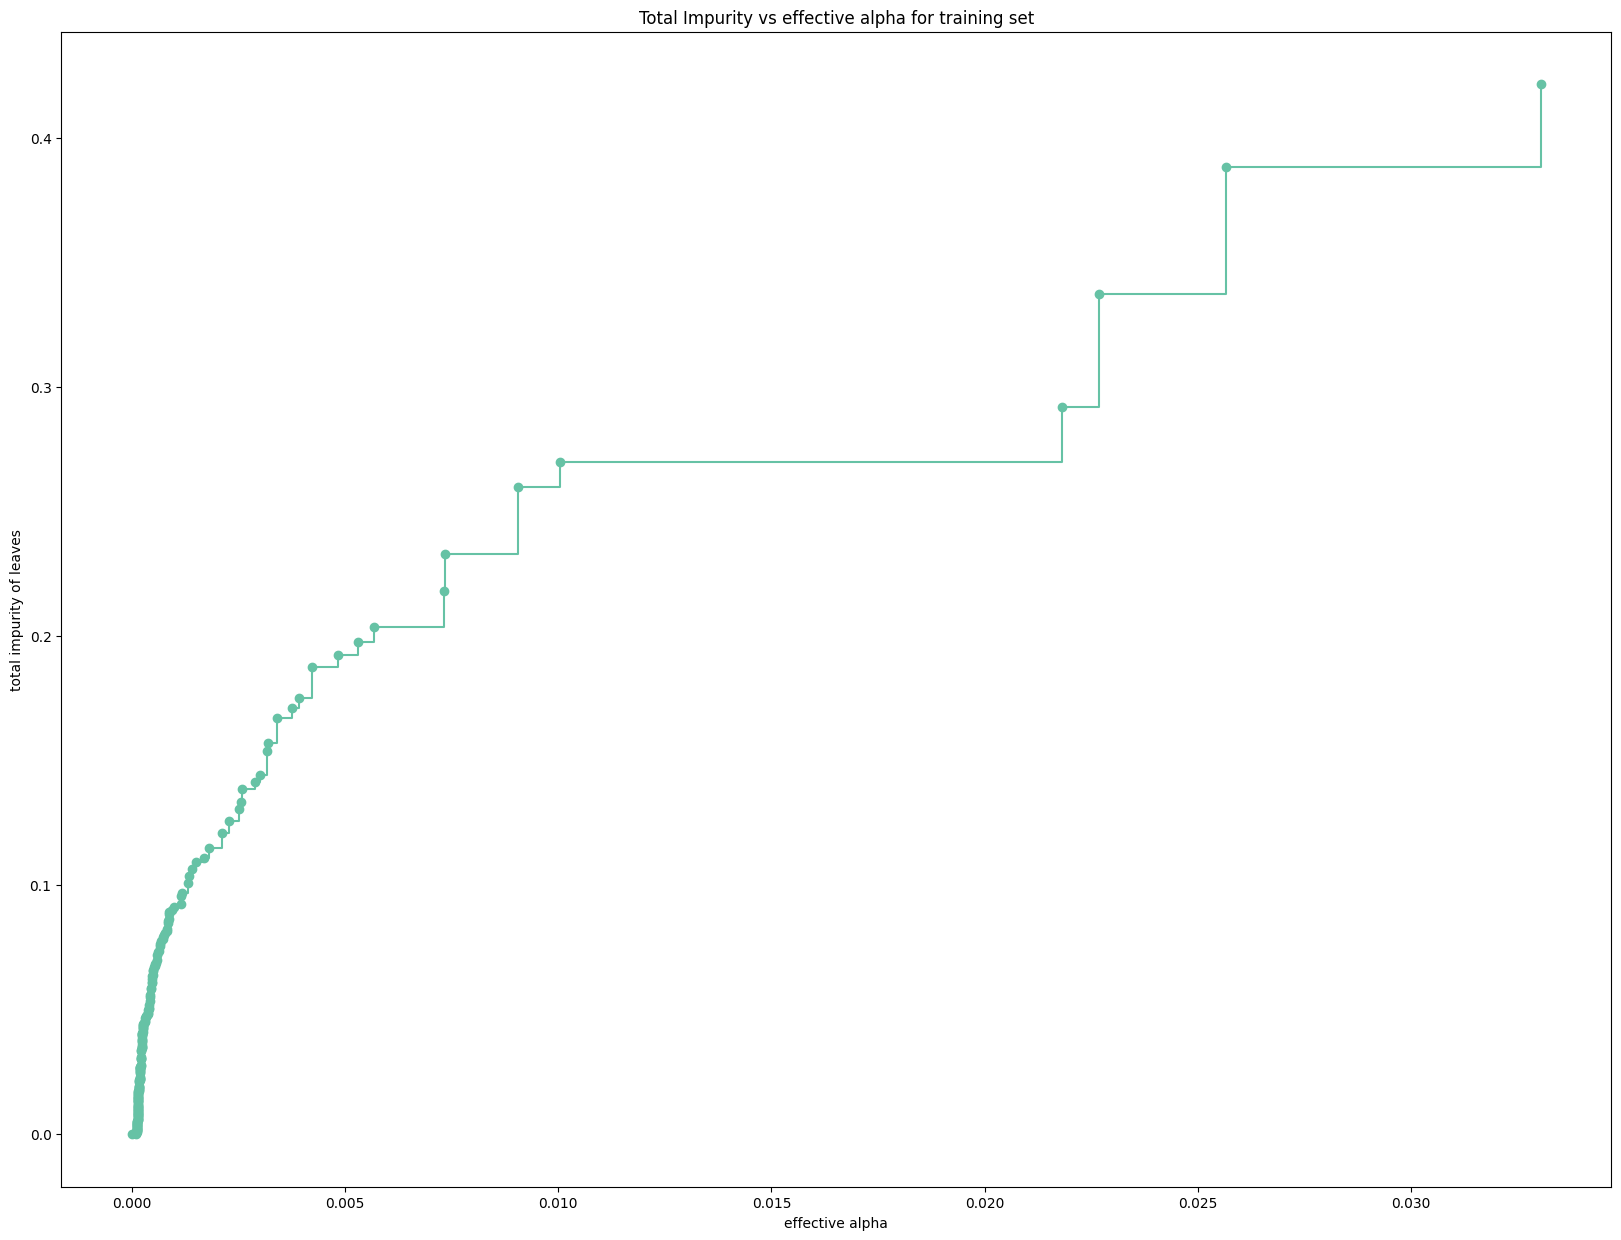

Number of nodes in the last tree is: 1 with ccp_alpha: 0.07791479566191767


In [ ]:
clf = DecisionTreeClassifier()
path = clf.cost_complexity_pruning_path(x_train, y_train) 
ccp_alphas, impurities = path.ccp_alphas, path.impurities
plt.figure(figsize=(20, 15))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("effective alpha")  
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs effective alpha for training set")
plt.show()
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

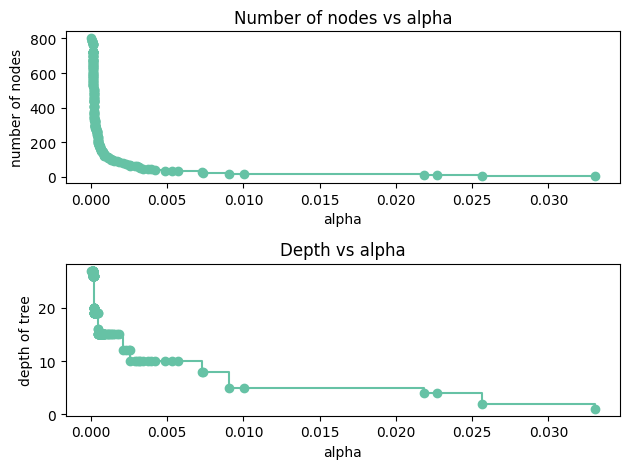

In [86]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Total Impurity of Leaves VS. Effective Alphas of Pruned Tree (Extra Tree)**

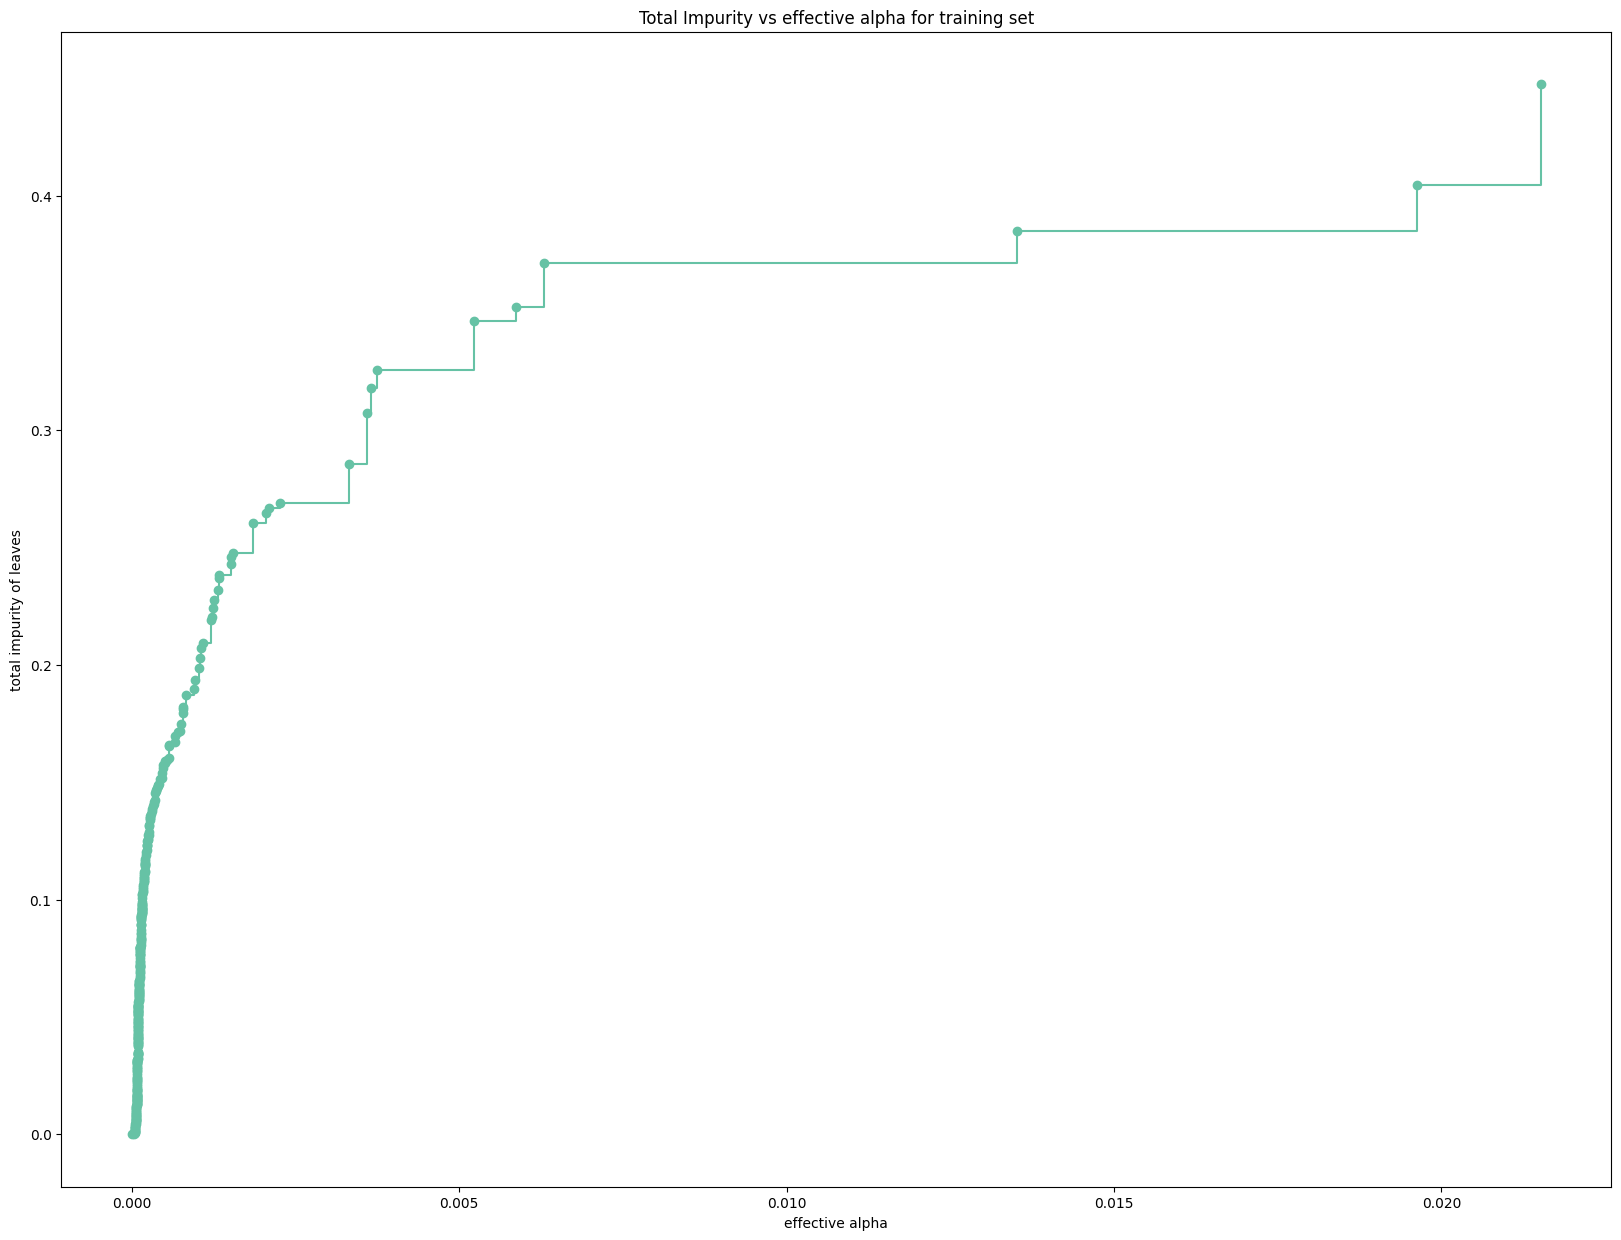

Number of nodes in the last tree is: 3 with ccp_alpha: 0.051851917672227354


In [ ]:
clf = ExtraTreeClassifier()
path = clf.cost_complexity_pruning_path(x_train, y_train) 
ccp_alphas, impurities = path.ccp_alphas, path.impurities

plt.figure(figsize=(20, 15))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs effective alpha for training set")
plt.show()

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)

print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

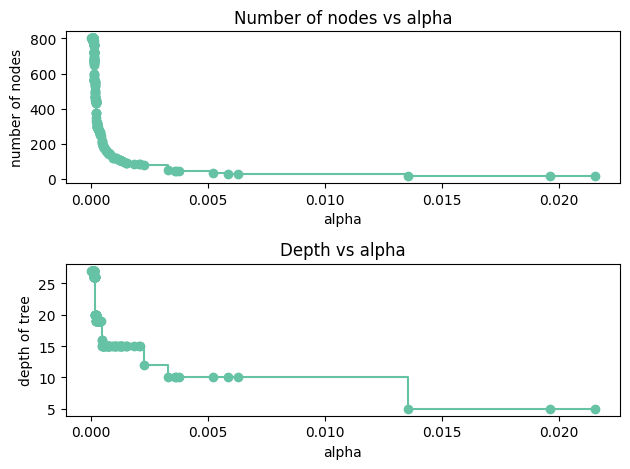

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()
plt.show()

**Interpreting the Complexity Plots**

The visualizations you generated are essential tools for understanding the Bias-Variance Trade-off in the context of pruning.

**Total Impurity vs. Effective Alpha**

- Initial Point (Alpha $\approx$ 0): The total impurity is near zero because the fully-grown tree (high complexity) fits the training data almost perfectly, leading to high variance.Trend: As $\alpha$ increases, the algorithm prunes the tree (removing nodes). The Total Impurity of Leaves necessarily increases because the tree is less capable of fitting the specific details of the training data.
- Purpose: This plot confirms that the pruning process is working: we sacrifice a small amount of training purity for a simpler model.

**Number of Nodes / Depth vs. Alpha**

- Inverse Relationship: Both the Number of Nodes and the Depth of the Tree decrease sharply as $\alpha$ increases. This directly visualizes the reduction in model complexity.
- Steps: The plots are stepped because a range of $\alpha$ values can correspond to the same optimal subtree. Only at specific "critical" $\alpha$ values does a single branch get cut, leading to a sudden step-down in complexity (node count and depth).
- Significance: These graphs help identify the range of $\alpha$ values that lead to a substantial reduction in complexity without causing a massive jump in training impurity.

**The Bias-Variance Trade-Off in Pruning**

Pruning is the classic demonstration of managing the Bias-Variance Trade-off:

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-hs1k{border-color:inherit;color:#1B1C1D;font-size:100%;font-weight:bold;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-hs1k">Tree State</th>
    <th class="tg-7zrl">Bias</th>
    <th class="tg-7zrl">Variance</th>
    <th class="tg-7zrl">Training Performance</th>
    <th class="tg-0lax">Generalization (Test)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Unpruned (Low α)</td>
    <td class="tg-7zrl">Low (fits data well)</td>
    <td class="tg-7zrl">High (overfits noise)</td>
    <td class="tg-7zrl">Excellent (high accuracy)</td>
    <td class="tg-7zrl">Poor/Unreliable</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Optimally Pruned (Optimal α)</td>
    <td class="tg-7zrl">Moderate</td>
    <td class="tg-7zrl">Low (less sensitive to data changes)</td>
    <td class="tg-7zrl">Very Good</td>
    <td class="tg-0lax">Excellent (stable and robust)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Overly Pruned (High α)</td>
    <td class="tg-7zrl">High (too simple)</td>
    <td class="tg-7zrl">Low</td>
    <td class="tg-7zrl">Poor (underfits)</td>
    <td class="tg-7zrl">Poor</td>
  </tr>
</tbody></table>

The final step in CCP, which is usually done with cross-validation (like `GridSearchCV or cross_val_score`), is to select the $\alpha$ that finds the sweet spot, maximizing the model's accuracy on the unseen validation data.

**Hyperparameters Tuning (Decision Tree and Extra Tree Comparison)**

To systematically find the best set of hyperparameters that maximize the model's performance on unseen data, leading to a more robust and accurate model. Performig Grid Search Cross-Validation to find the optimal hyperparameters for both DecisionTreeClassifier and ExtraTreeClassifier. It defines a param_grid for each model, specifying a range of values for various hyperparameters. GridSearchCV then systematically tries every possible combination of these parameters, evaluates them using cross-validation, and identifies the combination that yields the best performance (highest accuracy in this case).

**Decision Tree and Extra Tree Hyperparameters**

**Hyperparameters**: Configuration settings that are external to the model and whose values cannot be estimated from the data. Examples include the splitting criterion (`gini, entropy`), maximum depth of the tree (`max_depth`), minimum samples required to split an internal node (`min_samples_split`), etc. These parameters are divided into three main categories: splitting quality, tree size constraints, and feature randomization.

**1. Splitting Quality (`criterion and min_impurity_decrease`)**

These parameters dictate the mathematical rules for deciding if and how a node should be 

- `split.criterion (gini, entropy, log_loss)`: This defines the function used to measure the quality of a split. The model attempts to maximize the reduction in node impurity after a split occurs. Gini impurity (`gini`) measures the probability of misclassifying a random sample in a node. Entropy (or `log_loss`) measures the randomness or disorder, aiming for a split that maximizes Information Gain.
- `min_impurity_decrease (0.0, 0.1, 0.2)`: This sets a threshold for how much a potential split must reduce the overall impurity of the tree to be considered valid. Setting this value higher (e.g., to $0.2$) forces the model to ignore minor, insignificant splits, leading to a smaller, more generalizable tree and helping to prevent overfitting .


**2. Tree Size Constraints (`max_depth, min_samples_split, min_samples_leaf, ccp_alpha`)**

These are the primary controls used to regulate the model's complexity, directly fighting overfitting.

- `max_depth (None, 5, 10, 15, 20)`: This defines the absolute maximum number of levels the tree is allowed to grow. If set to None, the tree grows until every leaf is pure (all samples in the leaf belong to one class) or until it hits the minimum sample requirements. Limiting the depth is a straightforward way to prune the tree and reduce variance.
- `min_samples_split (2, 5, 10)`: This specifies the minimum number of data samples required in an internal node before the model will consider splitting it further. A higher value (e.g., $10$) ensures that the splits are based on a larger, more representative group of samples, avoiding the classification of small, potentially noisy data segments.
- `min_samples_leaf (1, 2, 4)`: This sets the minimum number of data samples that must reside in a newly created leaf node. Requiring at least two or more samples per leaf forces the final decision regions to be larger and more generalized, providing structural resistance against overfitting.
- `ccp_alpha (0.0, 0.01, 0.1)`: This is the parameter for Cost-Complexity Pruning (CCP), which controls the penalty for tree complexity. When $\alpha$ is $0.0$, no pruning occurs, resulting in the largest tree. As $\alpha$ increases (e.g., to $0.1$), the tree is heavily penalized for having many nodes, leading to an aggressively pruned, simpler tree. This is the most sophisticated method for finding the optimal complexity/generalization trade-off.


**3. Feature Randomization (`max_features`)**

This parameter controls the randomness introduced at the node level, which is particularly vital for ensemble methods like the Extra Tree Classifier.

- `max_features (sqrt, log2, None)`: This defines the maximum number of features the model will consider when searching for the best split at any given node. None means all features are always considered. Using a subset like sqrt (square root of total features) or log2 introduces randomness. For Decision Trees, this helps reduce variance; for Extra Trees, it's a foundational mechanism, complementing the random split threshold selection to ensure each tree in the ensemble is highly diverse.

**Grid Search Hyperparameters**

**Grid Search**: An exhaustive search through a manually specified subset of the hyperparameter space. For each combination, a model is trained and evaluated using cross-validation.

* `n_jobs=-1`: Utilizes all available CPU cores for parallel processing, significantly speeding up the grid search.

* `verbose=1`: Provides detailed output during the search process.

* `best_params_ and best_score_`: Attributes of the GridSearchCV object that store the best hyperparameter combination found and the corresponding cross-validation score.

In [ ]:
# Define the parameter grids for each model 
param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None], 
    'min_impurity_decrease': [0.0, 0.1, 0.2],
    'ccp_alpha': [0.0, 0.01, 0.1]
}

param_grid_et = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'min_impurity_decrease': [0.0, 0.1, 0.2],
    'ccp_alpha': [0.0, 0.01, 0.1]
}

# Define the models
models = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(), param_grid_dt),
    ("ExtraTreeClassifier", ExtraTreeClassifier(), param_grid_et)
]

# Perform GridSearchCV for each model
for model_name, base_model, param_grid in models:
    print(f"{model_name} Hyperparameter Tuning:")
    
    # Initialize StratifiedKFold
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=skf,
        scoring='accuracy',
        n_jobs=-1,  # Use all available cores
        verbose=1
    )
    
    # Fit the grid search
    grid_search.fit(x_train, y_train)
    
    # Print results
    print(f"\tBest Parameters: {grid_search.best_params_}")
    print(f"\tBest Cross-Validation Score: {grid_search.best_score_:.4f}")
    print("-" * 100)
    
    # Train the model with the best parameters
    best_model = grid_search.best_estimator_
    best_model.fit(x_train, y_train)
    
    # Optional: Perform cross-validation with the best model
    cv_scores = cross_val_score(best_model, x_train, y_train, cv=skf, scoring='accuracy')
    print(f"\tCross-Validation Scores with Best Model: {cv_scores}")
    print(f"\tAverage Cross-Validation Score: {cv_scores.mean():.4f}")
    print("-" * 100)

DecisionTreeClassifier Hyperparameter Tuning:
Fitting 10 folds for each of 3645 candidates, totalling 36450 fits
	Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5}
	Best Cross-Validation Score: 0.9389
----------------------------------------------------------------------------------------------------
	Cross-Validation Scores with Best Model: [0.94615385 0.94461538 0.93846154 0.93076923 0.93692308 0.93538462
 0.93692308 0.94307692 0.94153846 0.93528505]
	Average Cross-Validation Score: 0.9389
----------------------------------------------------------------------------------------------------
ExtraTreeClassifier Hyperparameter Tuning:
Fitting 10 folds for each of 3645 candidates, totalling 36450 fits
	Best Parameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_spl

The results of your Grid Search show that for this dataset, both models favored a complex structure (low $\alpha$, high depth) combined with basic leaf constraints ($\text{min\_samples\_leaf} \ge 1$), indicating the data is highly separable and benefits from the model's high capacity.

**Decision Boundary (Decision Tree Tuned Model)**

After finding the best hyperparameters, this code visualizes the decision surface of the best_estimator_ (the model trained with the optimal hyperparameters) on the 2-dimensional PCA features. To visually confirm the impact of hyperparameter tuning on the model's decision-making process and to ensure the decision boundary is well-defined and generalizes well.

* **Optimized Decision Boundary:** This visualization shows how the decision boundary looks after the model has been tuned with the best hyperparameters. It allows for a visual assessment of whether the tuning process has resulted in a more sensible or effective separation of classes.

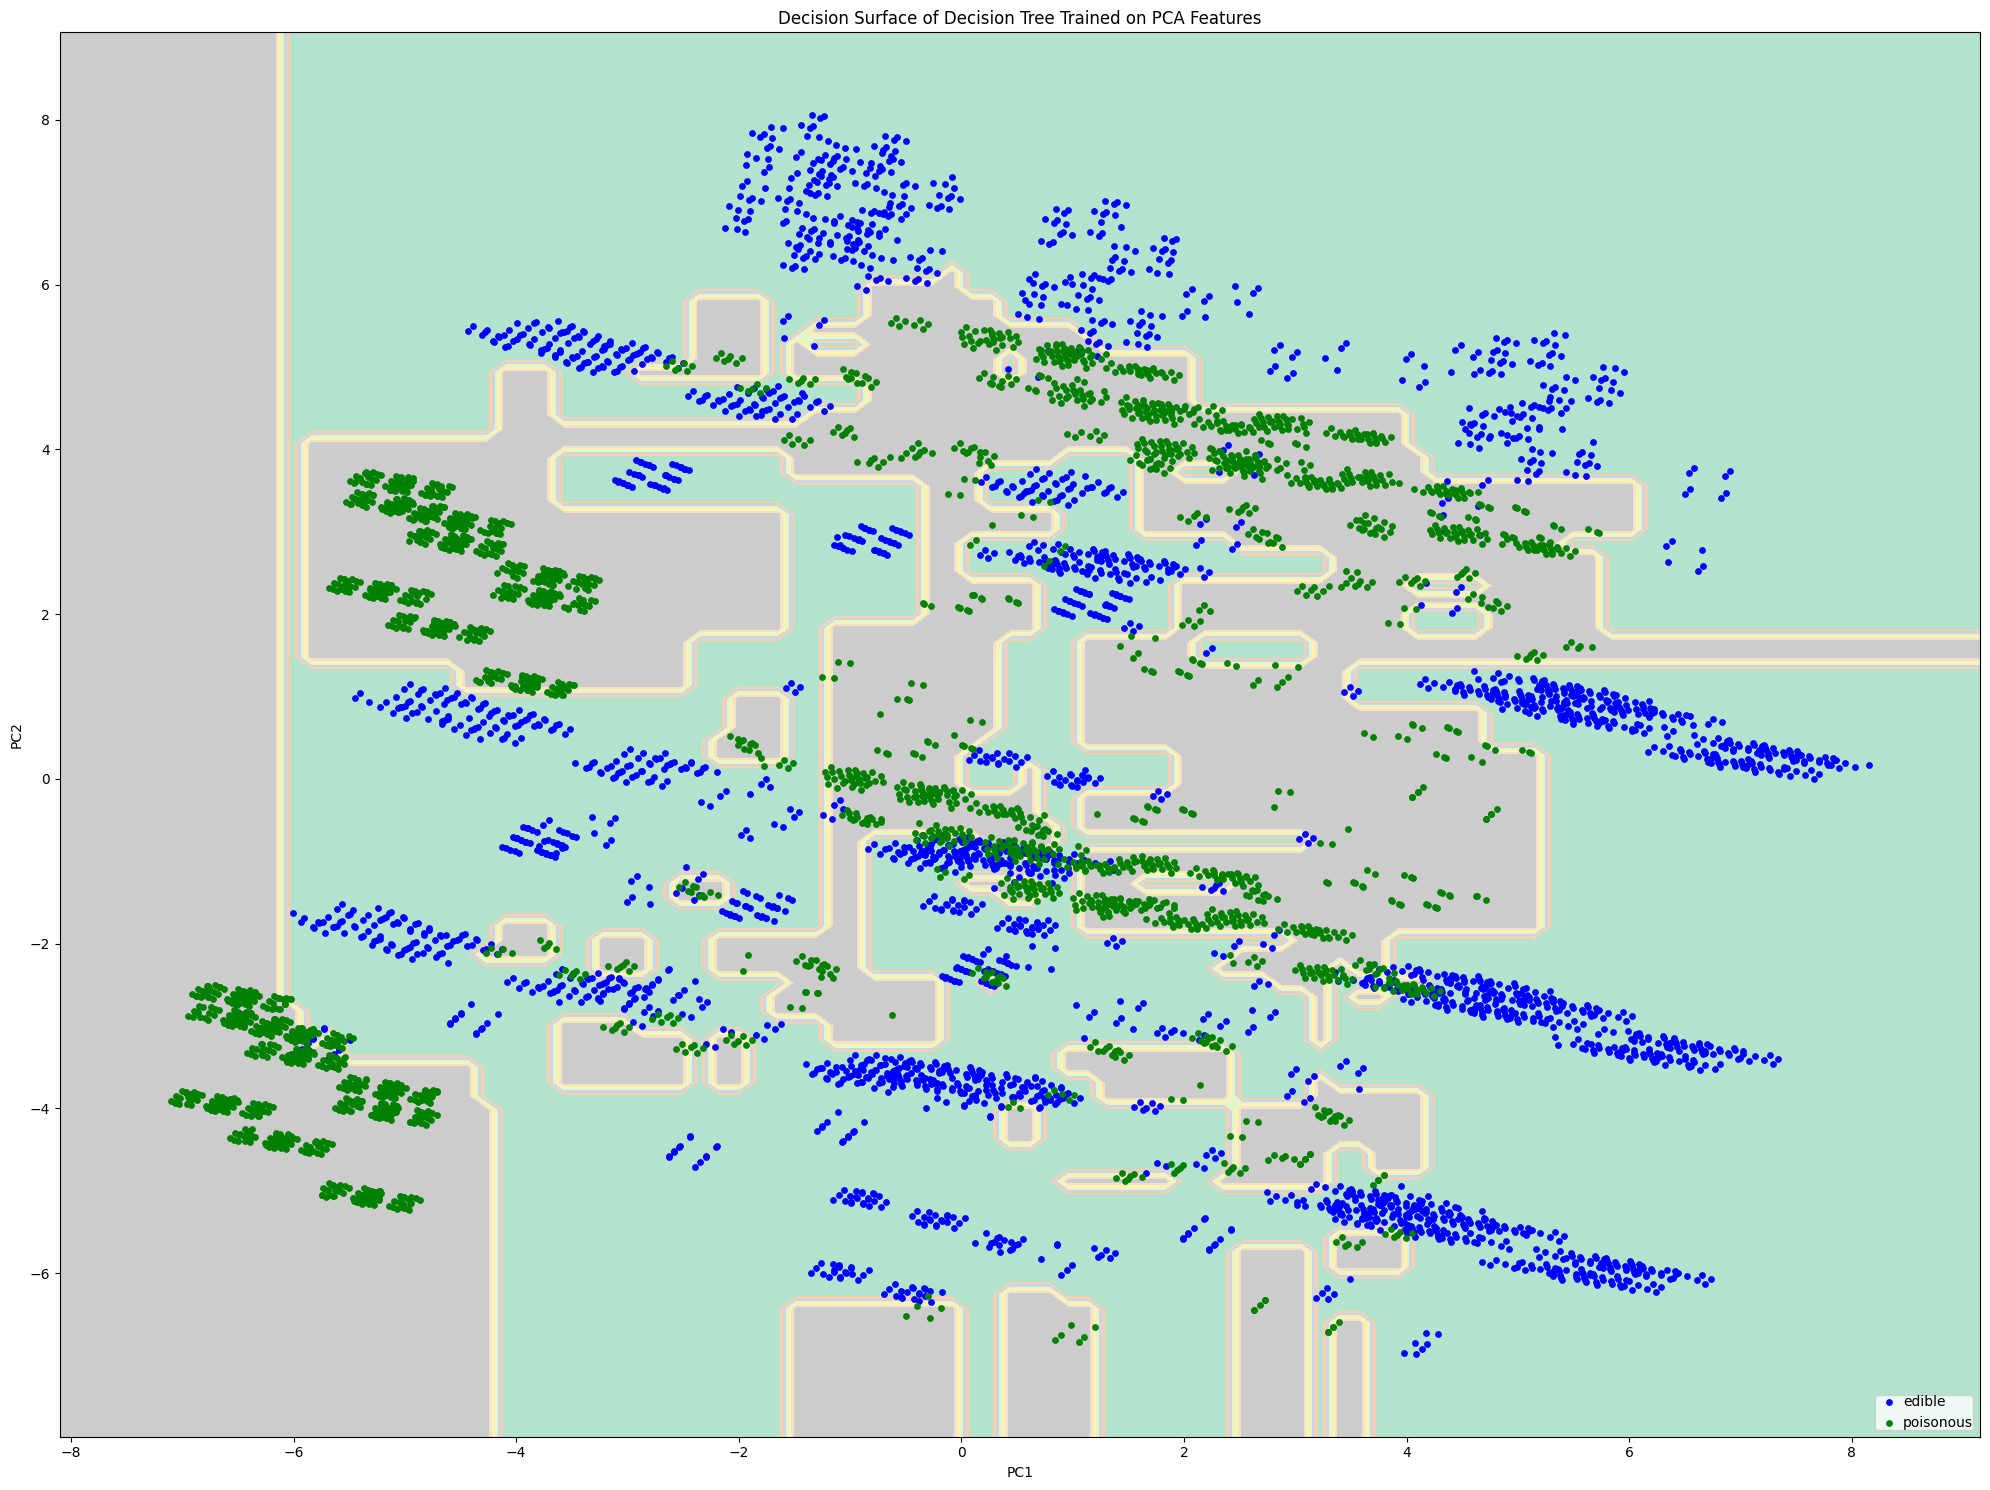

In [ ]:
n_classes = 2
plot_colors = "bg"
plot_step = 0.02

feature_names = ['PC1', 'PC2']

X_pair = x_train[:, [0, 1]]
y_pair = y_train

clf_pair = grid_search.best_estimator_.fit(X_pair, y_pair)

fig, ax = plt.subplots(figsize=(20, 15))

DecisionBoundaryDisplay.from_estimator(
    clf_pair,
    X_pair,
    cmap=plt.cm.Pastel2,
    response_method="predict",
    ax=ax,
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)

for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y_pair == i)
    ax.scatter(
        X_pair[idx, 0],
        X_pair[idx, 1],
        c=color,
        label=label_encoder.inverse_transform([i])[0],
        s=15,
    )

ax.set_title("Decision Surface of Decision Tree Trained on PCA Features")
ax.legend(loc="lower right", borderpad=0, handletextpad=0)

plt.tight_layout()
plt.show()

# Model Evaluation

Model evaluation is the process of assessing the performance of a machine learning model on unseen data. This is crucial to ensure that the model can generalize well to new, real-world examples.

**Best Model Training and Cross-Validation**

The best_model (obtained from GridSearchCV) is first fitted (trained) on the entire PCA-transformed training dataset (x_train, y_train). Then, cross-validation is performed on both the training (x_train) and testing (x_test) datasets to get a more reliable estimate of the model's performance.

In [ ]:
best_model = grid_search.best_estimator_.fit(x_train, y_train)

print("\nCross-Validation for Best DecisionTreeClassifier Model on train dataset:")
print('-' * 100)
cv_scores = cross_val_score(best_model, x_train, y_train, cv=skf, scoring='accuracy')
print(f"\tK-Fold Cross-Validation: {cv_scores}")
print(f"\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print('-' * 100)

print("\nCross-Validation for Best DecisionTreeClassifier Model on test dataset:")
print('-' * 100)
cv_scores = cross_val_score(best_model, x_test, y_test, cv=skf, scoring='accuracy')
print(f"\tK-Fold Cross-Validation: {cv_scores}")
print(f"\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print('-' * 100)


Cross-Validation for Best DecisionTreeClassifier Model on train dataset:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.95230769 0.94923077 0.92153846 0.89538462 0.94307692 0.92461538
 0.93692308 0.94461538 0.93230769 0.91679507]
	Average K-Fold Cross-Validation Accuracy: 0.932 ± 0.017
----------------------------------------------------------------------------------------------------

Cross-Validation for Best DecisionTreeClassifier Model on test dataset:
----------------------------------------------------------------------------------------------------
	K-Fold Cross-Validation: [0.88957055 0.88957055 0.90184049 0.90797546 0.88957055 0.85185185
 0.89506173 0.90740741 0.88271605 0.87037037]
	Average K-Fold Cross-Validation Accuracy: 0.889 ± 0.016
----------------------------------------------------------------------------------------------------


**Accuracy vs Alpha (Train VS. Test Dataset)**

To visually determine the best ccp_alpha for pruning by observing the point where the test accuracy is highest, thus finding the most generalized model. This plot visualizes the accuracy of the decision tree on both the training and testing sets as a function of `ccp_alpha`. This helps in understanding the impact of pruning on model performance and identifying the optimal alpha value.

**Bias-Variance Trade-off**: This plot is a classic illustration of the bias-variance trade-off.

* **At low alpha values (less pruning)**, the tree is complex, leading to high training accuracy but potentially lower test accuracy (overfitting).

* **As alpha increases (more pruning)**, the tree becomes simpler. Training accuracy might decrease, but test accuracy might initially increase (reducing variance) before eventually decreasing (increasing bias if too much information is lost).

**Optimal Pruning**: The ideal `ccp_alpha` is often where the test accuracy is maximized, representing a good balance between bias and variance.

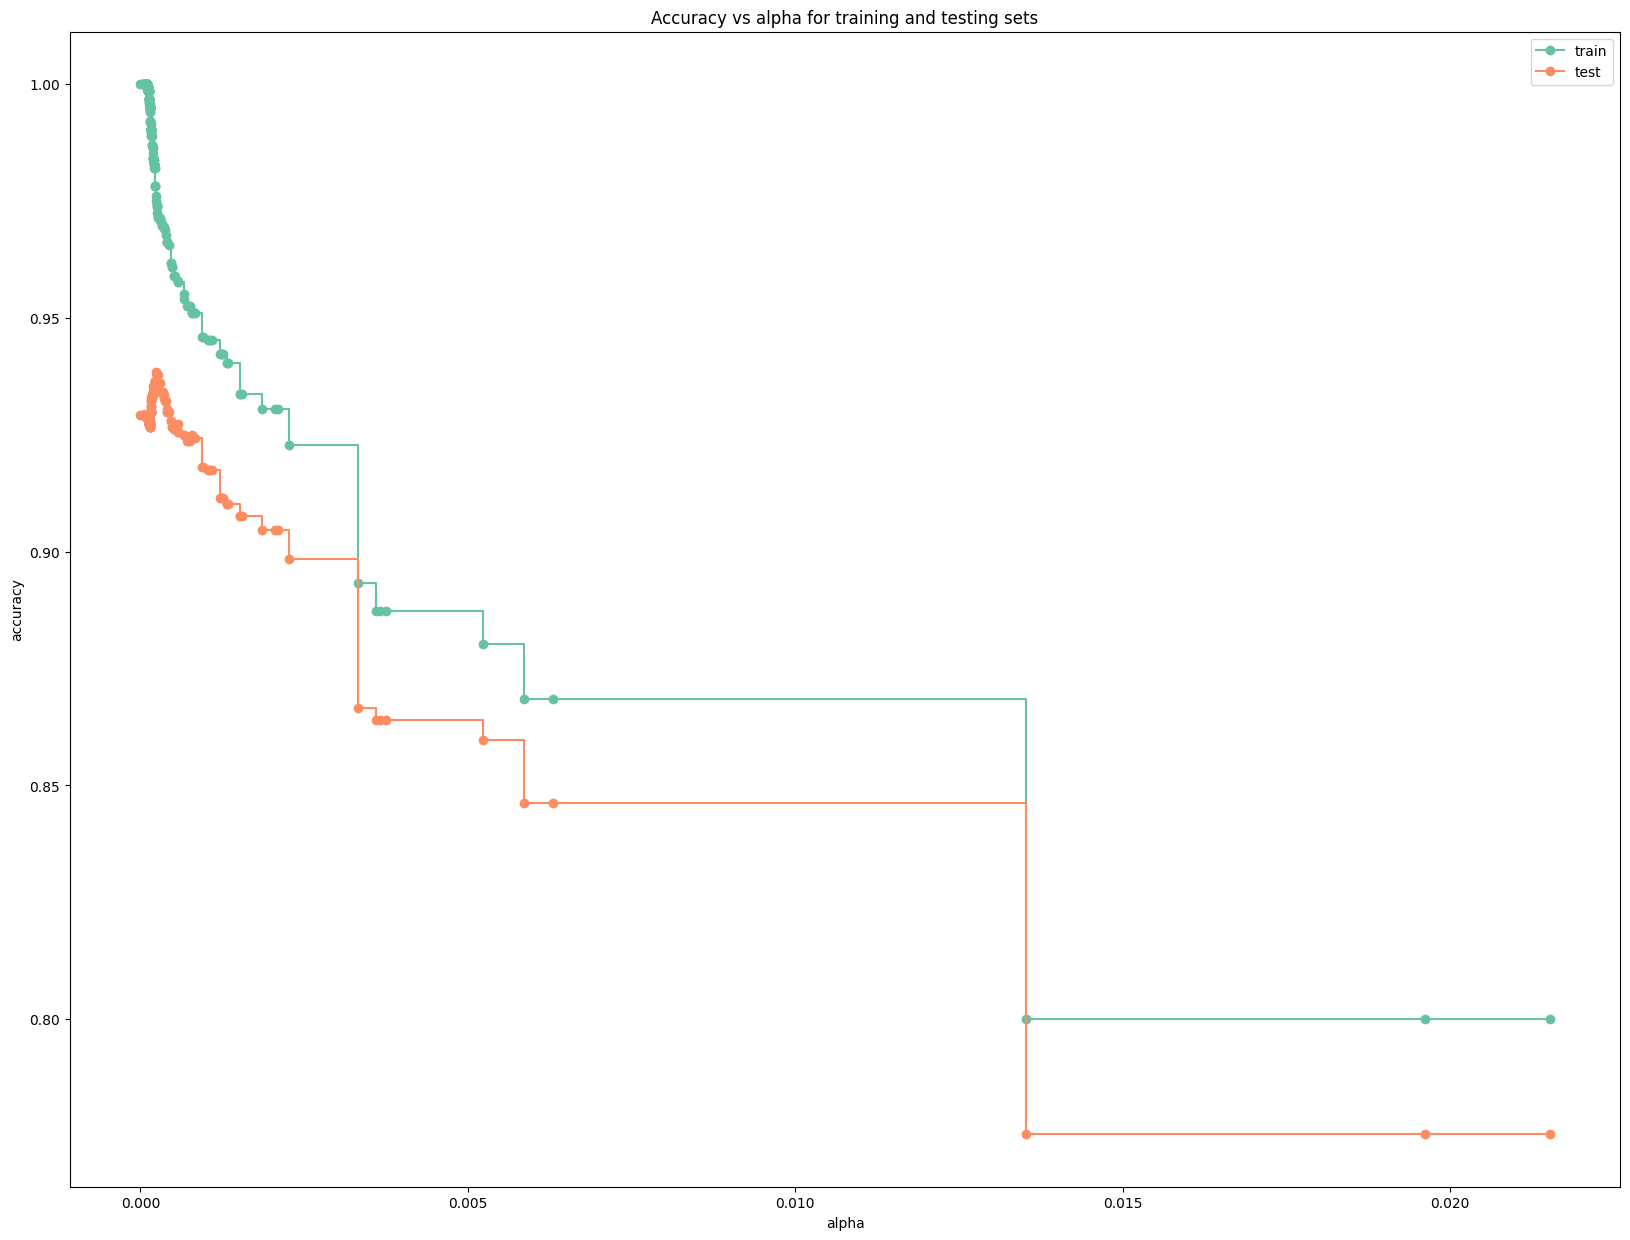

In [ ]:
train_scores = [clf.score(x_train, y_train) for clf in clfs]
test_scores = [clf.score(x_test, y_test) for clf in clfs]

plt.figure(figsize=(20, 15))

plt.xlabel("alpha")
plt.ylabel("accuracy")
plt.title("Accuracy vs alpha for training and testing sets")

plt.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")

plt.legend()

plt.show()

**Classification Reports Evaluation**

This section calculates and prints various classification metrics for the best_model on the test set, including accuracy, precision, recall, F1-score, and AUC-ROC. It also generates a detailed classification report.

**Classification Metrics**

**Accuracy:** The proportion of correctly predicted instances out of the total instances.

**Precision:** For a given class, it's the ratio of correctly predicted positive observations to the total predicted positive observations. High precision means a low false positive rate.

**Recall (Sensitivity):** For a given class, it's the ratio of correctly predicted positive observations to all observations in the actual class. High recall means a low false negative rate.

**F1-Score:** The harmonic mean of precision and recall. It provides a single metric that balances both. It's particularly useful when dealing with imbalanced datasets.

**AUC-ROC (Area Under the Receiver Operating Characteristic Curve):** A measure of a classifier's ability to distinguish between classes. An AUC of 1 represents a perfect classifier, while an AUC of 0.5 represents a classifier no better than random guessing. It's robust to class imbalance.

**Classification Report:** Provides a comprehensive summary of precision, recall, and F1-score for each class, along with support (number of actual occurrences of each class).

* `average='macro'`: Calculates metrics for each label and finds their unweighted mean. This does not take label imbalance into account.

* `zero_division=1`: Handles cases where there are no true instances of a class (or no predicted instances), preventing division-by-zero errors in metrics like precision and recall by setting the score to 1.

In [ ]:
y_pred = best_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)  
recall = recall_score(y_test, y_pred, average='macro', zero_division=1)  
f1 = f1_score(y_test, y_pred, average='macro', zero_division=1)  

y_pred_proba = best_model.predict_proba(x_test)[:, 1]  

roc_auc = roc_auc_score(y_test, y_pred_proba) 

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Accuracy: 0.937
Precision: 0.937
Recall: 0.937
F1-score: 0.937
AUC-ROC: 0.964

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       843
           1       0.93      0.93      0.93       782

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625



**Confusion Matrix**

This final step calculates and visualizes the confusion matrix for the best_model's predictions on the test set.

**Confusion Matrix:** A table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It shows the number of:

* True Positives (TP): Correctly predicted positive cases.

* True Negatives (TN): Correctly predicted negative cases.

* False Positives (FP): Incorrectly predicted positive cases (Type I error).

* False Negatives (FN): Incorrectly predicted negative cases (Type II error).

A heatmap visualization of the confusion matrix makes it easy to see where the model is performing well and where it is making mistake.


Class distribution in y_test: [843 782]
Class distribution in y_pred: [844 781]


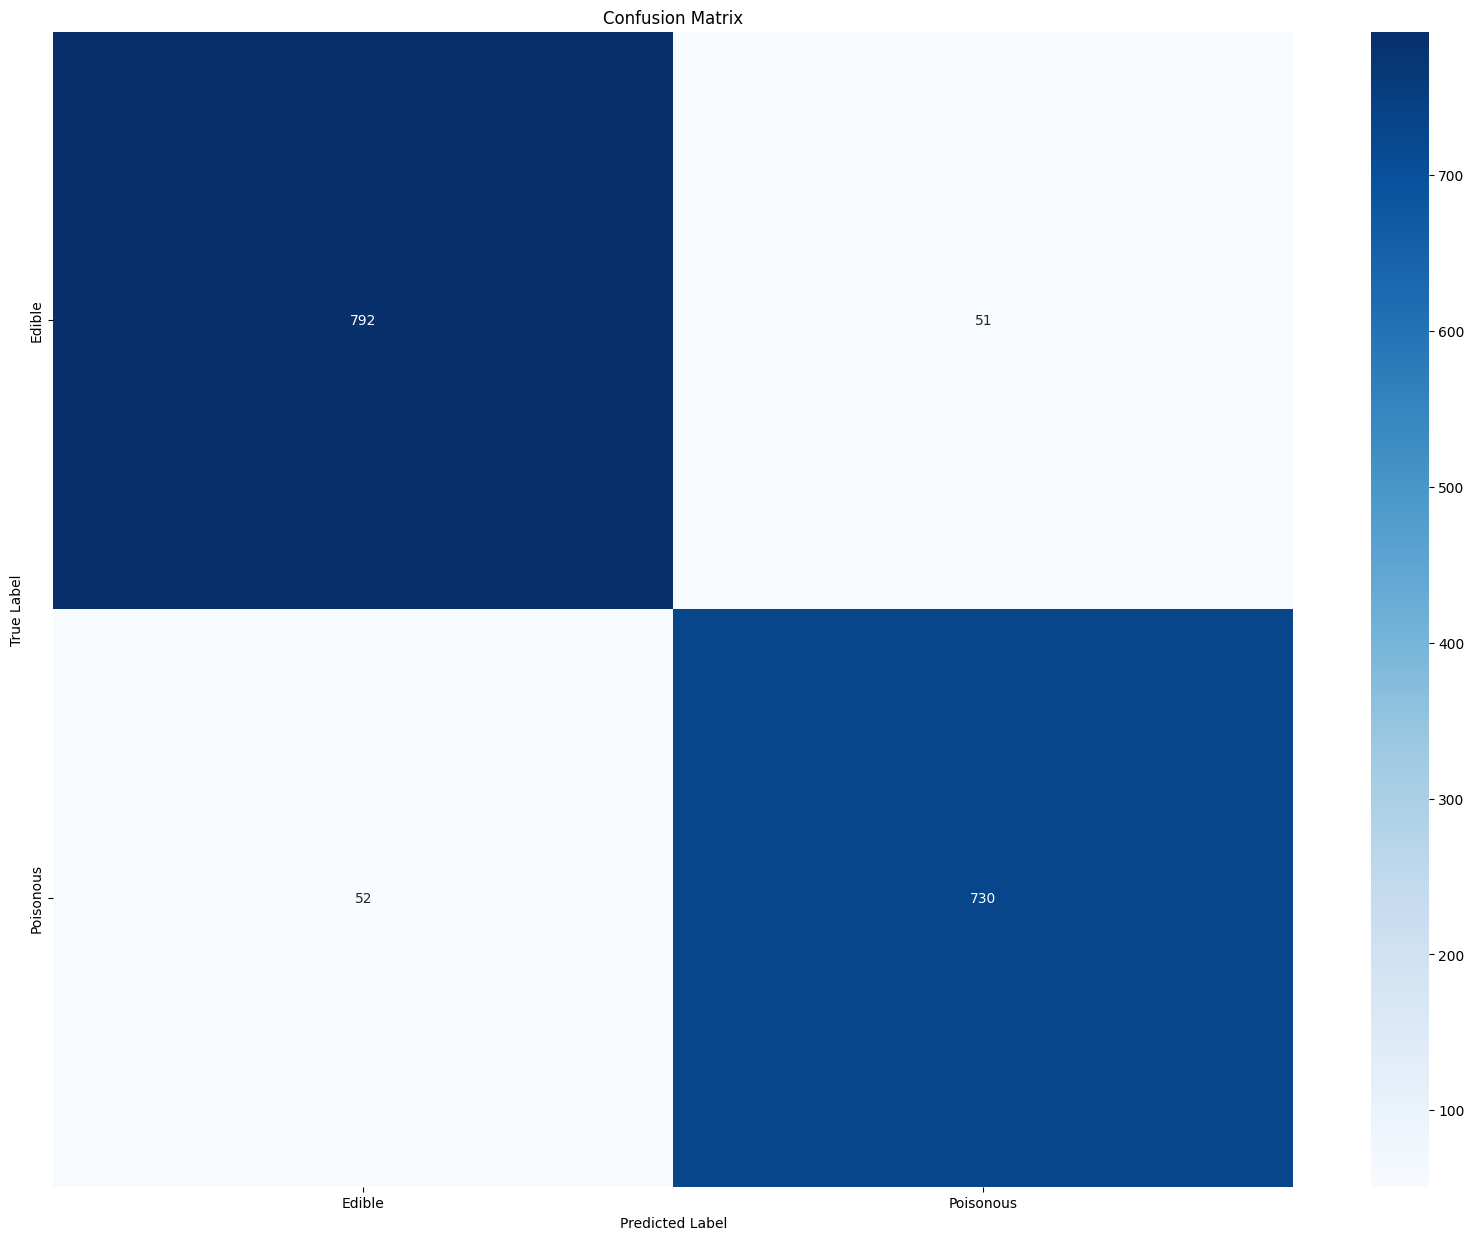

In [ ]:
print("\nClass distribution in y_test:", np.bincount(y_test))
print("Class distribution in y_pred:", np.bincount(y_pred))

class_names = ["Edible", "Poisonous"]  # Mapping: 0=Hernia, 1=Normal, 2=Spondylolisthesis

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**Precision Recall Curve**

PR curves are particularly useful when dealing with imbalanced datasets or when the cost of false positives or false negatives varies significantly. For instance, in a medical diagnosis, high recall might be preferred to avoid missing positive cases, even at the cost of some false positives. If the "poisonous" class is relatively rare but its correct identification is crucial, a PR curve for "poisonous" would be more informative than an ROC curve because it focuses on the performance on the minority positive class.

**Precision-Recall Curve:** A PR curve illustrates the trade-off between precision and recall for different probability thresholds of a classifier.

**Precision (Positive Predictive Value):** The proportion of true positive predictions among all positive predictions ($TP/(TP+FP)$). It tells us, "Of all the instances the model predicted as positive, how many were actually positive?"

**Recall (Sensitivity or True Positive Rate):** The proportion of true positive predictions among all actual positive instances ($TP/(TP+FN)$). It tells us, "Of all the instances that were actually positive, how many did the model correctly identify?"

**Threshold Variation:** Classification models often output probabilities. To make a final class prediction, a threshold (e.g., 0.5) is applied. By varying this threshold from 0 to 1, we get different pairs of precision and recall values.

**One-vs-Rest (OvR):** In a multi-class setting (even if the dataset is binary, like edible/poisonous, it's treated generically here), OvR involves treating each class as the "positive" class and all other classes as the "negative" class. This allows for the calculation of class-specific PR curves. In this specific binary case, it effectively plots one curve for "Edible" (where "Edible" is positive and "Poisonous" is negative) and another for "Poisonous" (where "Poisonous" is positive and "Edible" is negative).

**Area Under the Curve (AUC-PR):** While not explicitly calculated and printed here, the area under the Precision-Recall curve (AUC-PR or Average Precision) is a single metric that summarizes the performance across all thresholds. A higher AUC-PR indicates better performance, especially when there is a class imbalance.

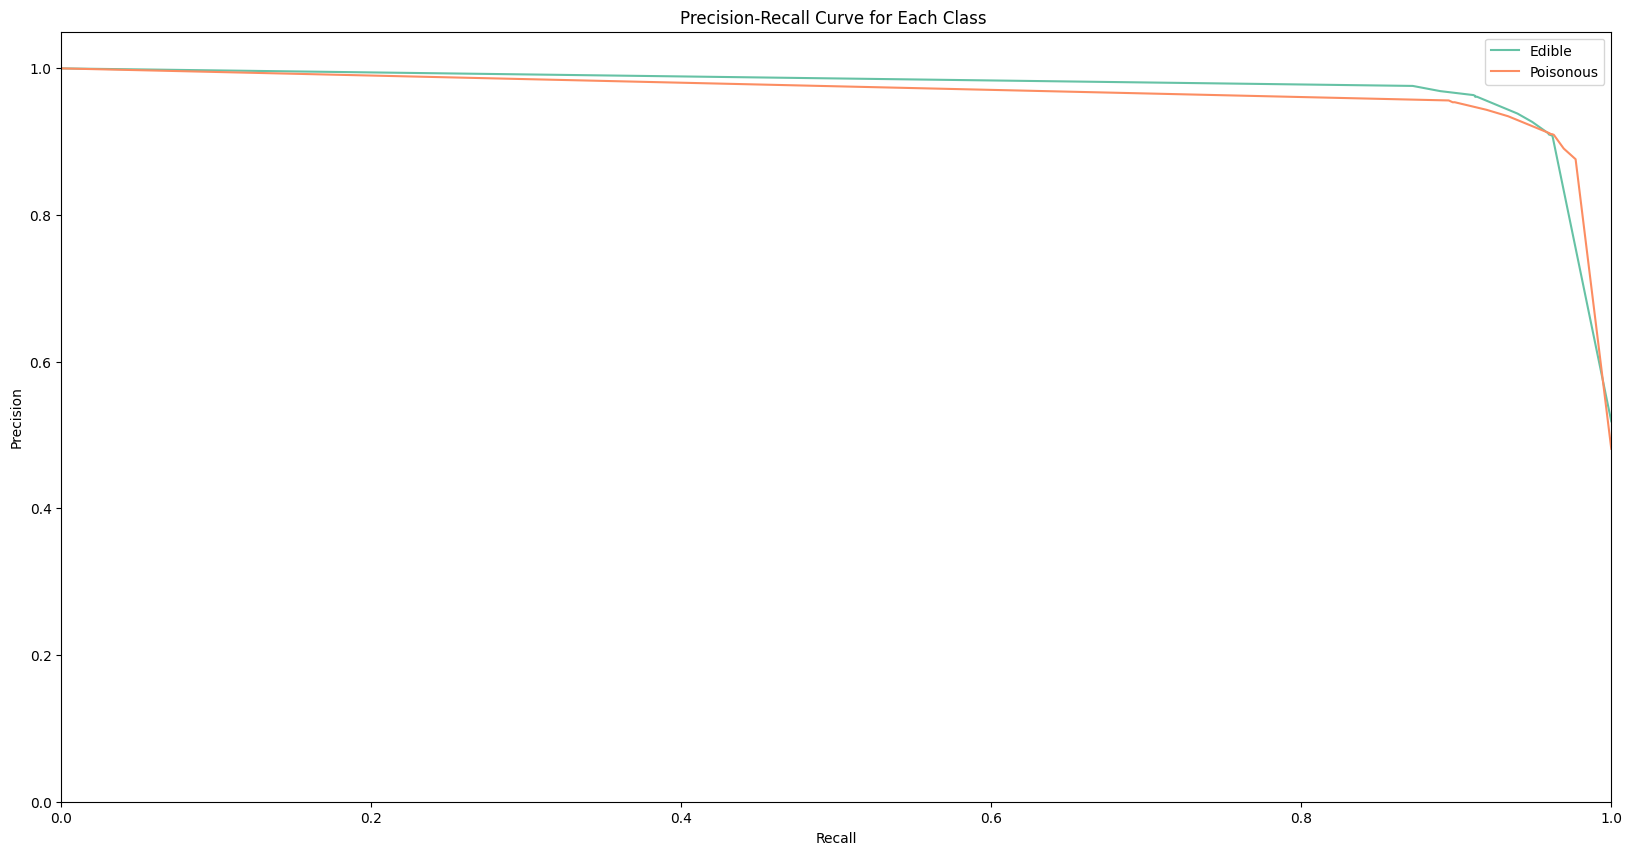

In [ ]:
class_labels = ["Edible", "Poisonous"]

y_test_labels = y_test.flatten()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, label in enumerate(class_labels):
  y_test_bin = np.where(y_test_labels == i, 1, 0)
  y_pred_prob = best_model.predict_proba(x_test)[:, i] 

  precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_prob)

  plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class ")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])

plt.show()

**ROC AUC Curve**

ROC curves and AUC scores are widely used for evaluating binary classifiers. They are particularly robust to class imbalance because they consider both true positives and true negatives across all thresholds. A high AUC-ROC indicates that the model is good at distinguishing between positive and negative classes. It helps in selecting a model or determining an optimal operating point based on the desired balance between TPR and FPR.

**ROC Curve:** An ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

* True Positive Rate (TPR) / Recall / Sensitivity: $$TP/(TP+FN)$$ The proportion of actual positives that are correctly identified.

* False Positive Rate (FPR): $$FP/(FP+TN)$$ The proportion of actual negatives that are incorrectly identified as positive.

**Threshold Variation:** Similar to the PR curve, the ROC curve is generated by changing the probability threshold used to classify instances.

**Area Under the ROC Curve (AUC-ROC):** The AUC-ROC score summarizes the overall performance of the classifier across all possible thresholds.

* An AUC of 1.0 indicates a perfect classifier.

* An AUC of 0.5 suggests a classifier no better than random guessing.

* An AUC less than 0.5 indicates a classifier that performs worse than random guessing (e.g., predicting the opposite of the true class).


------------------------------------------------------------------------------------------------------------------------------------------------------
Edible AUC: 0.9644

------------------------------------------------------------------------------------------------------------------------------------------------------
Poisonous AUC: 0.9644

------------------------------------------------------------------------------------------------------------------------------------------------------


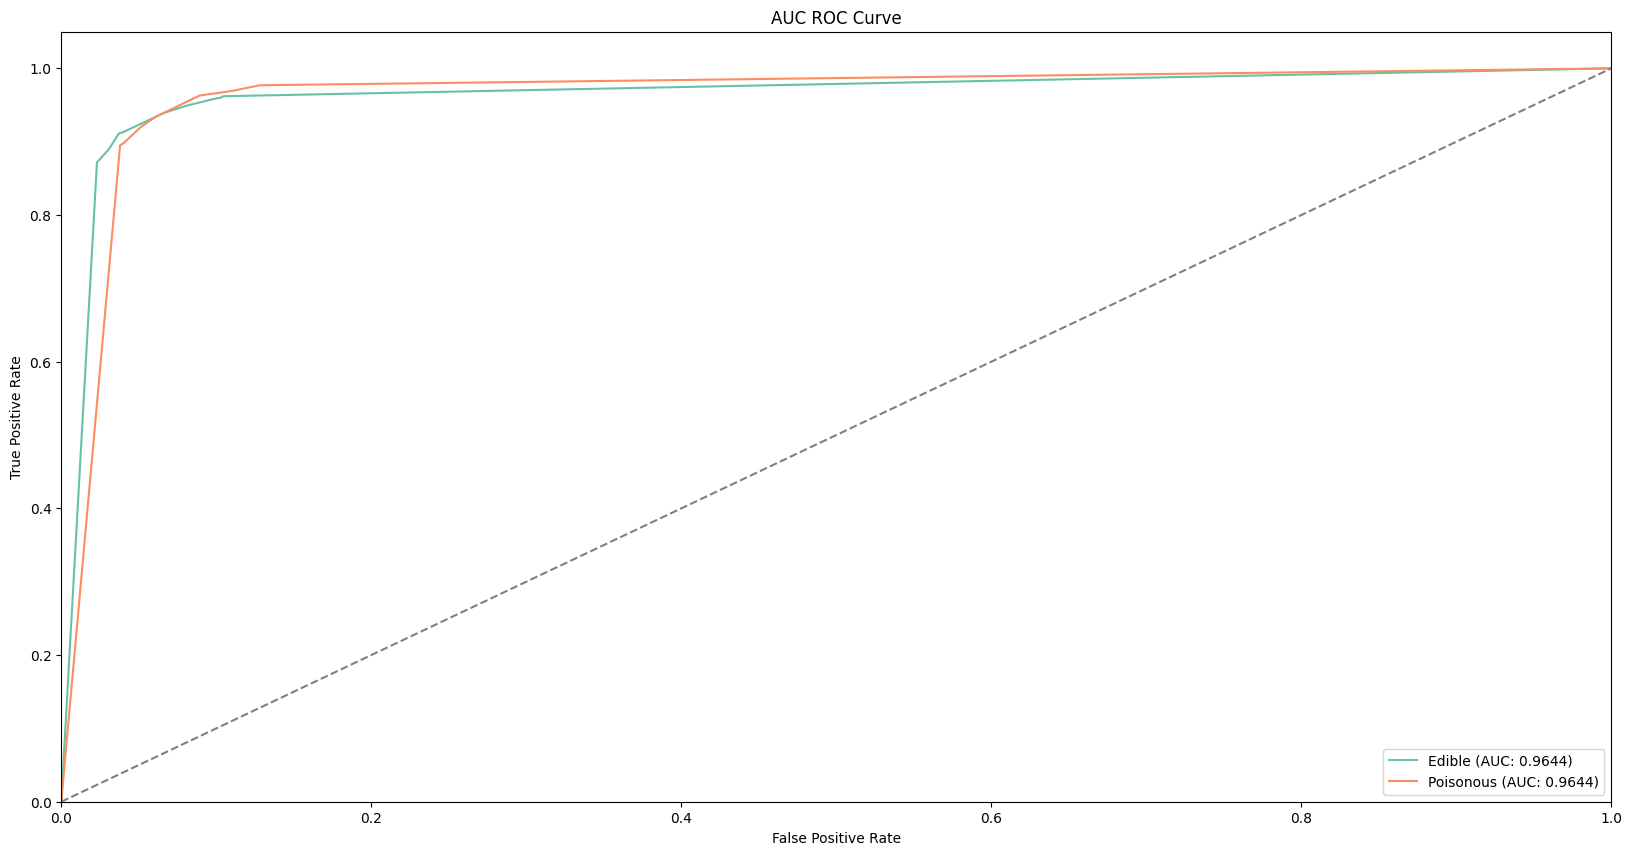

In [ ]:
y_pred = best_model.predict_proba(x_test)

class_labels = ["Edible", "Poisonous"]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(class_labels):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    fpr[i] = np.where(np.isinf(fpr[i]), np.nan, fpr[i])
    tpr[i] = np.where(np.isinf(tpr[i]), np.nan, tpr[i])
    mask = ~np.isnan(fpr[i]) & ~np.isnan(tpr[i])
    fpr[i] = fpr[i][mask]
    tpr[i] = tpr[i][mask]
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_label in enumerate(class_labels):
    sns.lineplot(x=fpr[i], y=tpr[i], label=f'{class_label} (AUC: {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC ROC Curve')
plt.legend(loc="lower right")

for i, class_label in enumerate(class_labels):
    print()
    print('-' * 150)
    print(f"{class_label} AUC: {roc_auc[i]:.4f}")
print()
print('-' * 150)
plt.show()

# Conclusion

This project successfully developed and optimized a robust machine learning pipeline for classifying mushrooms as edible or poisonous using Decision Tree (DTC) and Extra Tree (ETC) Classifiers. The analysis confirmed that both models are highly effective for this task, with the Tuned Decision Tree Classifier offering the optimal balance of accuracy and interpretability. Key Performance and Optimization Findings in this notebook are:

**Data Preparation and Feature Importance**

The pipeline effectively reduced complexity through preprocessing:

- Dimensionality Reduction (PCA) allowed the visualization of complex decision surfaces in a simple 2D space.
- Exploratory Data Analysis (EDA) revealed that features like odor, gill-color, and stalk-surface are the strongest predictors of class, driving the models' core logic.

**Model Accuracy and Selection**

Rigorous Grid Search Cross-Validation was essential for mitigating overfitting and boosting generalization:

- Baseline Performance: The DTC achieved a baseline cross-validation accuracy of ~93.8%, slightly better than the ETC's ~91.6%.
- Tuned Performance: The hyperparameter tuning process confirmed the DTC as the superior model, achieving a final test accuracy of 93.7% and an impressive AUC-ROC of 0.964.
- Pruning Analysis (CCP): Cost-Complexity Pruning was critical for visualizing the bias-variance trade-off. Analysis showed that while the unconstrained tree had high complexity, a moderate level of pruning improved generalization by removing weak, noisy splits.

**Model Behavior Insights**

Visualization of the models' decision boundaries provided key theoretical insights :

- DTC Decision Surfaces: The DTC created more intricate, tailored rectangular regions reflecting its goal of finding the locally optimal split (low bias, higher variance).
- ETC Decision Surfaces: The ETC produced somewhat simpler boundaries due to its randomized splitting strategy, confirming its focus on lower variance and more robust generalization, even at the cost of slightly lower accuracy.

**Practical Implications and Recommendations**

**Model Recommendation**

The Tuned Decision Tree Classifier is recommended for real-world deployment. Its superior accuracy (93.7%) combined with its high interpretability allows for clear identification of the critical features driving the edible/poisonous decision, a vital aspect for safety-critical applications.

**Safety-Critical Metrics**

Given the high risk associated with a False Negative (classifying a poisonous mushroom as edible), the model's balanced performance—with precision, recall, and F1-score all at 0.937—is essential, ensuring a reliable and safe solution.

**Future Work**

While the DTC performs excellently, future efforts should focus on:

- Exploring robust ensemble methods like Random Forests or Gradient Boosting to potentially squeeze out the final percentage of accuracy.
- Addressing the limitations of the highly separable Kaggle dataset by testing the pipeline on more complex, real-world data with missing values or greater noise.

# References

- [Scikit-Learn](http://scikit-learn.org/stable/)
- [Wikipedia](https://www.wikipedia.org/)
- [Geeksforgeeks](https://www.geeksforgeeks.org/)